# SGAM-MLP: X-IIoTID Final Research Notebook

This is the X-IIoTID multiclass intrusion-detection study.

**Execution workflow:** `PREPARE → TRAIN → FINAL → REPORT`

- `FINAL` performs the frozen-test evaluation.
- `REPORT` is the final reporting stage. It does **not** retrain the models; it regenerates tables, figures, statistical summaries, and explainability outputs from the saved experiment artifacts.
- Internal model IDs are retained in the code and storage paths for reproducibility. Publication-facing outputs use the professional model names below.

## Model Summary

| Model | What is added | Research role |
|---|---|---|
| **Class-Weighted XGBoost** | XGBoost + class weighting | Strong tree-based baseline for imbalanced multiclass intrusion detection |
| **Standard MLP** | Basic MLP only | Neural-network baseline without class weighting or feature masking |
| **Class-Weighted MLP** | Standard MLP + class weighting | Tests whether imbalance handling alone improves the MLP |
| **Random Feature Masking MLP** | Class-Weighted MLP + matched-size random feature masking | Control model for testing whether generic/random masking improves robustness |
| **Proposed Source-Group-Aware Masking Model (SGAM-MLP)** | Class-Weighted MLP + structured masking of **network, resource, and activity** feature groups | **Proposed model**; tests whether source-group-aware masking improves robustness to operational feature-group unavailability |

## Final experiment snapshot

- Dataset: **X-IIoTID**
- Records: **820,834**
- Active raw predictors: **56**
- Encoded inputs: **134**
- Source groups: **Network = 26, Resource = 24, Activity = 6**
- Seeds: **42, 123, 2026**
- Planned model/seed runs: **15**




In [ ]:
# @title Controls
STAGE = "REPORT"  # @param ["PREPARE", "TRAIN", "FINAL", "REPORT"]
RUNS_THIS_SESSION = 1  # @param {type:"integer"}
CONFIRM_FINAL_TEST = True  # @param {type:"boolean"}
EXPERIMENT_NAME = "source_group_v1"  # @param {type:"string"}
DEVICE_PREFERENCE = "auto"  # @param ["auto", "cpu"]
CHECKPOINT_EVERY_BATCHES = 300  # @param {type:"integer"}
SHOW_FIGURES = True  # @param {type:"boolean"}
ALLOW_PACKAGE_INSTALL = True  # @param {type:"boolean"}
AUTO_REPAIR_CPU_ONLY_TORCH_ON_GPU = True  # @param {type:"boolean"}

BASE_DIR = "/content/drive/MyDrive/XIIoTID_Research"
LOCAL_CACHE_DIR = "/content/XIIoTID_local_cache"

if RUNS_THIS_SESSION < 1 or CHECKPOINT_EVERY_BATCHES < 1:
    raise ValueError("Run/checkpoint counts must be positive.")

In [ ]:
# @title Environment setup and mount
import sys, subprocess, importlib.util, json, shutil

requirements = {
    "numpy": "numpy>=1.26,<3", "pandas": "pandas>=2.0,<3",
    "scipy": "scipy>=1.11,<2", "sklearn": "scikit-learn>=1.4,<2",
    "torch": "torch>=2.6,<3", "xgboost": "xgboost>=2.0,<4",
    "joblib": "joblib>=1.3,<2", "matplotlib": "matplotlib>=3.8,<4",
    "shap": "shap>=0.46,<1", "lime": "lime>=0.2.0.1"
}
missing = [spec for name, spec in requirements.items() if importlib.util.find_spec(name) is None]
if missing:
    if not ALLOW_PACKAGE_INSTALL:
        raise RuntimeError("Missing dependencies: " + ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

gpu_driver = None
if shutil.which("nvidia-smi"):
    probe = subprocess.run(["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"], capture_output=True, text=True)
    if probe.returncode == 0 and probe.stdout.strip():
        gpu_driver = int(probe.stdout.splitlines()[0].split(".")[0])

if gpu_driver and DEVICE_PREFERENCE == "auto" and AUTO_REPAIR_CPU_ONLY_TORCH_ON_GPU:
    probe = subprocess.run([sys.executable, "-c", "import torch,json; print(json.dumps({'cuda':torch.version.cuda,'ok':torch.cuda.is_available()}))"], capture_output=True, text=True)
    if probe.returncode == 0:
        info = json.loads(probe.stdout.strip().splitlines()[-1])
        if info["cuda"] is None and ALLOW_PACKAGE_INSTALL:
            index = "cu128" if gpu_driver >= 570 else ("cu126" if gpu_driver >= 560 else None)
            if index:
                already_imported = "torch" in sys.modules
                print("GPU is present but PyTorch is CPU-only. Repairing from the official PyTorch index...")
                install = subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "--force-reinstall", "torch>=2.6,<3", "--index-url", "https://download.pytorch.org/whl/" + index])
                if install.returncode == 0 and already_imported:
                    raise RuntimeError("PyTorch updated BEFORE training. Restart session once, then Run all with the same controls.")
                if install.returncode != 0:
                    print("GPU repair did not complete; existing CPU installation will be used if importable.")
            else:
                print("Automatic wheel selection is not attempted for this driver; CPU fallback remains available.")

from google.colab import drive
drive.mount("/content/drive")
print("Setup complete. Package imports/device will be checked by the engine.")

Mounted at /content/drive
Setup complete. Package imports/device will be checked by the engine.


In [ ]:
# @title 4A - Protocol and safe storage helpers
"""Embedded engine for the approved XIIoTID single-notebook protocol.
No external modules/data other than the user's CSV and standard ML packages.
"""
import os, sys, json, time, math, random, hashlib, shutil, tempfile, gc, platform
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import joblib
import torch
from torch import nn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve)
import xgboost as xgb
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value.to_string() if hasattr(value,'to_string') else value)

ENGINE_VERSION = '1.0.0'
EXPECTED_SHA = '7b9290057ee42e784da3c0d84b781815502c9205c74175c96374e71a5ffd98a0'
CLASSES = ['Normal','RDOS','Reconnaissance','Weaponization','Lateral_movement',
           'Exfiltration','Tampering','C&C','Exploitation','crypto-ransomware']
RESOURCE = ['Avg_user_time','Std_user_time','Avg_nice_time','Std_nice_time',
 'Avg_system_time','Std_system_time','Avg_iowait_time','Std_iowait_time',
 'Avg_ideal_time','Std_ideal_time','Avg_tps','Std_tps','Avg_rtps','Std_rtps',
 'Avg_wtps','Std_wtps','Avg_ldavg_1','Std_ldavg_1','Avg_kbmemused','Std_kbmemused',
 'Avg_num_Proc/s','Std_num_proc/s','Avg_num_cswch/s','std_num_cswch/s']
ACTIVITY = ['Login_attempt','Succesful_login','File_activity','Process_activity',
            'read_write_physical.process','is_privileged']
FLAGS = ['is_syn_only','Is_SYN_ACK','is_pure_ack','is_with_payload','FIN or RST',
         'Bad_checksum','is_SYN_with_RST']
CATS = ['Protocol','Service']
EXCLUDE = ['Date','Timestamp','Scr_IP','Des_IP','anomaly_alert','OSSEC_alert',
           'OSSEC_alert_level','class1','class2','class3']
BINARY = FLAGS + ACTIVITY + ['Conn_state']
METHODS = ['XGBoost_CW','MLP','MLP_CW','MLP_CW_Random','MLP_CW_Group']
CONDITIONS = ['original','no_network','no_resource','no_activity',
              'random_network_size','random_resource_size','random_activity_size']
GROUPS = ['network','resource','activity']
PROTOCOL = dict(version=ENGINE_VERSION, seeds=[42,123,2026], split_seed=42,
    split_target=[.70,.15,.15], proxy_seconds=300, hidden=[128,64], dropout=.1,
    epochs=30, batch_size=512, learning_rate=.001, weight_decay=.0001,
    patience=5, weight_power=.5, mask_probability=.5,
    xgb_rounds=800, xgb_patience=50, xgb_chunk=25, xgb_max_depth=6,
    xgb_learning_rate=.05, inference_batch=4096, bootstrap_reps=1000,
    mask_seed=73191, diagnostic_C=1., clean_guard_pp=1.,
    checkpoint_selection='original_validation_macro_f1',
    primary='mean_macro_f1_three_group_missing_conditions',
    tuning='fixed_hyperparameters_no_grid_search',
    inference_timing='preprocessed_original_input_same_session',
    expected_sha=EXPECTED_SHA, expected_rows=820834)


def file_sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for b in iter(lambda:f.read(4*1024*1024),b''): h.update(b)
    return h.hexdigest()


def canonical_hash(obj):
    return hashlib.sha256(json.dumps(obj,sort_keys=True,separators=(',',':')).encode()).hexdigest()


def atomic(path, writer):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    # Exactly one same-directory temporary file per atomic operation.
    tmp=path.with_name(path.stem+'.pending'+path.suffix)
    writer(tmp)
    os.replace(tmp,path)


def save_json(path,obj):
    def write(p):
        with p.open('w',encoding='utf-8') as f: json.dump(obj,f,indent=2,ensure_ascii=False,allow_nan=False)
    atomic(path,write)


def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def save_npz(path,**arrays):
    def write(p):
        with p.open('wb') as f: np.savez_compressed(f,**arrays)
    atomic(path,write)


def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark=False
    torch.use_deterministic_algorithms(True,warn_only=True)


def init_context(base, experiment, local_root, device_preference='auto', protocol=None):
    if not experiment or any(c not in 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-' for c in experiment):
        raise ValueError('Use a simple experiment name: letters, digits, _ or -.')
    p=dict(PROTOCOL if protocol is None else protocol)
    base=Path(base); root=base/'experiments'/experiment; local=Path(local_root)/experiment
    for folder in [root/'protocol',root/'models',root/'results',root/'report',local]: folder.mkdir(parents=True,exist_ok=True)
    fp=canonical_hash(p)
    lock=root/'protocol'/'protocol.json'
    if lock.exists():
        if read_json(lock)['fingerprint']!=fp: raise RuntimeError('Protocol changed. Restore settings or use a NEW experiment name; never overwrite this study.')
    else: save_json(lock,dict(fingerprint=fp,protocol=p))
    cuda_ok=torch.cuda.is_available() and torch.version.cuda is not None
    device='cuda' if cuda_ok and device_preference!='cpu' else 'cpu'
    torch.set_num_threads(min(4,os.cpu_count() or 2))
    env=dict(python=sys.version.split()[0],numpy=np.__version__,pandas=pd.__version__,
             torch=torch.__version__,xgboost=xgb.__version__,device=device,
             cuda_build=torch.version.cuda,platform=platform.platform())
    if device=='cuda': env['gpu']=torch.cuda.get_device_name(0)
    ctx=dict(base=base,root=root,local=local,p=p,fp=fp,device=device,env=env,
             csv=base/'data'/'X-IIoTID_dataset.csv')
    print('Device:',device,'| PyTorch CUDA build:',torch.version.cuda)
    if device=='cpu': print('CPU fallback active. GPU selection alone cannot fix a CPU-only PyTorch installation.')
    print('Study folder:',root)
    print('Stage completion:',status(ctx).to_string(index=False))
    return ctx


def model_path(c,m,s): return c['root']/'models'/f'{m}__s{s}'
def result_path(c,m,s): return c['root']/'results'/f'{m}__s{s}.npz'
def model_done(c,m,s): return model_path(c,m,s).with_suffix('.done.json').exists()


def status(c):
    return pd.DataFrame([dict(method=m,seed=s,trained=model_done(c,m,s),
          evaluated=result_path(c,m,s).exists()) for m in METHODS for s in c['p']['seeds']])


def storage_check(c, budget_gib=3.):
    used=sum(p.stat().st_size for p in c['root'].rglob('*') if p.is_file())
    print(f'Experiment artifacts: {used/2**20:.1f} MiB (CSV excluded).')
    if used>budget_gib*2**30: raise RuntimeError('Experiment exceeded the 3 GiB artifact budget. No automatic deletion; inspect storage before continuing.')
    # Drive-mounted statvfs does not reliably report Google Drive quota.
    return used


def union_groups(*arrays):
    n=len(arrays[0]); parent=np.arange(n); size=np.ones(n,dtype=np.int64)
    def find(i):
        while parent[i]!=i: parent[i]=parent[parent[i]]; i=parent[i]
        return i
    for a in arrays:
        ix=np.argsort(a,kind='stable'); same=a[ix[1:]]==a[ix[:-1]]
        for u,v in zip(ix[:-1][same],ix[1:][same]):
            x,z=find(u),find(v)
            if x!=z:
                if size[x]<size[z]: x,z=z,x
                parent[z]=x; size[x]+=size[z]
    return pd.factorize(np.array([find(i) for i in range(n)]))[0].astype('int32')


def fingerprints(frame):
    return np.column_stack([pd.util.hash_pandas_object(frame,index=False,hash_key=k).to_numpy()
                            for k in ['0123456789abcdef','fedcba9876543210']])


def factor_hash(a): return pd.factorize(pd.MultiIndex.from_arrays([a[:,0],a[:,1]]))[0]

In [ ]:
# @title 4B - Cleaning, groups, split and preprocessing
def local_raw(c):
    manifest=c['local']/'raw_manifest.json'
    if manifest.exists():
        r=read_json(manifest)
        if r['sha']==c['p']['expected_sha'] and all((c['local']/f).exists() for f in ['num.npy','cat.npy','y.npy','group.npy']): return r
    if not c['csv'].is_file(): raise FileNotFoundError('CSV is missing: '+str(c['csv']))
    print('Verifying CSV and building temporary local arrays; no Drive copy of arrays.')
    if file_sha(c['csv'])!=c['p']['expected_sha']: raise RuntimeError('CSV checksum differs from the approved dataset. Stop before training.')
    cols=pd.read_csv(c['csv'],nrows=0).columns.tolist()
    predictors=[x for x in cols if x not in EXCLUDE]
    if len(predictors)!=58 or not set(RESOURCE+ACTIVITY+FLAGS+CATS).issubset(predictors): raise RuntimeError('Unexpected CSV schema.')
    numcols=[x for x in predictors if x not in CATS]; n=c['p']['expected_rows']
    nr=np.lib.format.open_memmap(c['local']/'num.npy',mode='w+',dtype='float64',shape=(n,len(numcols)))
    cr=np.lib.format.open_memmap(c['local']/'cat.npy',mode='w+',dtype='int16',shape=(n,2))
    yy=np.lib.format.open_memmap(c['local']/'y.npy',mode='w+',dtype='uint8',shape=(n,))
    hashes=np.empty((n,2),dtype='uint64'); proxyhash=np.empty_like(hashes)
    vocabs={x:{'<MISSING>':0} for x in CATS}; events={x:Counter() for x in numcols}
    missing_counts=Counter(); hierarchy={}; offset=0; invalid_proxy=0
    for ch in pd.read_csv(c['csv'],dtype='string',keep_default_na=False,chunksize=25000):
        ch=ch.apply(lambda s:s.str.strip()); k=len(ch); end=offset+k
        if end>n: raise RuntimeError('Too many rows.')
        target=ch['class2'].replace({'Lateral _movement':'Lateral_movement'})
        if not target.isin(CLASSES).all(): raise RuntimeError('Unknown target label.')
        for a,b,z in ch[['class1','class2','class3']].drop_duplicates().itertuples(index=False,name=None):
            if a in hierarchy and hierarchy[a]!=(b,z): raise RuntimeError('Inconsistent label hierarchy.')
            hierarchy[a]=(b,z)
        yy[offset:end]=target.map({v:i for i,v in enumerate(CLASSES)}).to_numpy(dtype='uint8')
        clean=pd.DataFrame(index=ch.index)
        for j,col in enumerate(numcols):
            s=ch[col]; low=s.str.lower(); marker=low.isin(['','?','-','na','n/a','nan','none','null'])
            if col in FLAGS: v=low.map({'true':1.,'false':0.})
            else: v=pd.to_numeric(s.mask(marker),errors='coerce')
            a=v.to_numpy(dtype='float64',na_value=np.nan)
            bad=~marker.to_numpy() & np.isnan(a)
            events[col]['malformed']+=int(bad.sum())
            events[col]['negative']+=int((a<0).sum())
            events[col]['infinite']+=int(np.isinf(a).sum())
            a[~np.isfinite(a) | (a<0)]=np.nan
            if col in BINARY:
                illegal=np.isfinite(a)&~np.isin(a,[0,1]); events[col]['nonbinary']+=int(illegal.sum()); a[illegal]=np.nan
            nr[offset:end,j]=a
            clean[col]=pd.Series(a,index=ch.index).astype(str)
            missing_counts[col]+=int(np.isnan(a).sum())
        for j,col in enumerate(CATS):
            s=ch[col].mask(ch[col].str.lower().isin(['','?','nan','null','n/a']),'<MISSING>')
            for value in sorted(s.unique()):
                if value not in vocabs[col]: vocabs[col][value]=len(vocabs[col])
            cr[offset:end,j]=s.map(vocabs[col]).to_numpy(dtype='int16'); clean[col]=s
            missing_counts[col]+=int((s=='<MISSING>').sum())
        hashes[offset:end]=fingerprints(clean[predictors])
        ts=pd.to_numeric(ch['Timestamp'],errors='coerce').to_numpy(dtype=float,na_value=np.nan)
        valid=np.isfinite(ts)&(ts>=946684800)&(ts<1893456000)
        for col in ['Scr_IP','Des_IP','Scr_port','Des_port','Protocol']:
            valid &= ~ch[col].str.lower().isin(['','?','-','nan','none','null','na']).to_numpy()
        invalid_proxy+=int((~valid).sum())
        scr=ch['Scr_IP']+':'+ch['Scr_port']; dst=ch['Des_IP']+':'+ch['Des_port']; order=scr<=dst
        proxy=pd.DataFrame({'a':scr.where(order,dst),'b':dst.where(order,scr),'p':ch['Protocol'],
            'window':np.floor(np.where(valid,ts,0)/c['p']['proxy_seconds']).astype('int64').astype(str),
            'unknown':['' if ok else f'row_{offset+i}' for i,ok in enumerate(valid)]})
        proxyhash[offset:end]=fingerprints(proxy)
        offset=end
        print(f'Prepared raw rows {offset:,}/{n:,}',flush=True)
    if offset!=n: raise RuntimeError('Row count mismatch.')
    nr.flush(); cr.flush(); yy.flush()
    dup=factor_hash(hashes); prox=factor_hash(proxyhash)
    mix=pd.DataFrame({'g':dup,'y':np.asarray(yy)}).groupby('g').y.nunique()
    if (mix>1).any(): raise RuntimeError('Cleaned identical predictors have conflicting labels. Resolve before training; no rows silently removed.')
    group=union_groups(dup,prox); np.save(c['local']/'group.npy',group)
    np.save(c['local']/'duplicate_group.npy',dup.astype('int32'))
    np.save(c['local']/'proxy_group.npy',prox.astype('int32'))
    info=dict(sha=c['p']['expected_sha'],rows=n,predictors=predictors,numcols=numcols,vocabs=vocabs,
              events={k:dict(v) for k,v in events.items()},missing_counts=dict(missing_counts),
              group_count=int(len(np.unique(group))),largest_group=int(np.bincount(group).max()),
              invalid_proxy_rows=invalid_proxy,duplicate_excess=int(n-len(np.unique(dup))))
    save_json(manifest,info)
    del nr,cr,yy,hashes,proxyhash; gc.collect()
    return info


def get_raw(c):
    return tuple(np.load(c['local']/f,mmap_mode='r') for f in ['num.npy','cat.npy','y.npy','group.npy'])


def make_split(c,y,g):
    path=c['root']/'protocol'/'split.npz'
    if path.exists():
        with np.load(path) as z: split={k:z[k] for k in ['train','val','test']}
    else:
        rows=np.arange(len(y)); tr,rest=next(GroupShuffleSplit(n_splits=1,test_size=.3,random_state=c['p']['split_seed']).split(rows,y,g))
        va,te=next(GroupShuffleSplit(n_splits=1,test_size=.5,random_state=c['p']['split_seed']).split(rest,y[rest],g[rest]))
        split={'train':np.sort(tr),'val':np.sort(rest[va]),'test':np.sort(rest[te])}
    if not np.array_equal(np.sort(np.concatenate(list(split.values()))),np.arange(len(y))): raise RuntimeError('Split row coverage failed.')
    gs=[set(g[v]) for v in split.values()]
    if any(gs[i]&gs[j] for i in range(3) for j in range(i)): raise RuntimeError('Group leakage in split.')
    for name,ix in split.items():
        if len(np.unique(y[ix]))!=len(CLASSES): raise RuntimeError(f'{name} lacks a class. No seed search or row-level fallback is allowed.')
    if not path.exists(): save_npz(path,**split)
    return split


def fit_transform_spec(r,num,cat,tr):
    numeric=[]; categorical=[]; blocks=[]; names=[]; position=0
    for j,col in enumerate(r['numcols']):
        a=np.asarray(num[tr,j]); finite=a[np.isfinite(a)]
        if len(finite)==0 or (np.ptp(finite)==0 and len(finite)==len(a)): continue
        log=col not in BINARY # fixed nonnegative log1p + train-only standardization
        med=float(np.median(finite)); a=np.where(np.isfinite(a),a,med)
        if log: a=np.log1p(a)
        mean=float(a.mean()); std=float(a.std()); std=std if std>1e-8 else 1.
        numeric.append(dict(col=col,raw=j,median=med,log=log,mean=mean,std=std,pos=position))
        blocks.append([position]); names.append(col); position+=1
    for j,col in enumerate(CATS):
        present=sorted(set(map(int,cat[tr,j])))
        # Explicit missing and unknown slots, learned vocabulary only from train.
        known=[x for x in present if x!=0]
        categorical.append(dict(col=col,raw=j,known=known,pos=position,width=len(known)+2))
        blocks.append(list(range(position,position+len(known)+2))); names.append(col); position+=len(known)+2
    active=[a['col'] for a in numeric]+[a['col'] for a in categorical]
    indicator_start=position
    for i in range(len(active)): blocks[i].append(indicator_start+i)
    groups={g:[] for g in GROUPS}
    for i,col in enumerate(active): groups['resource' if col in RESOURCE else 'activity' if col in ACTIVITY else 'network'].append(i)
    return dict(numeric=numeric,categorical=categorical,active=active,blocks=blocks,groups=groups,
                indicator_start=indicator_start,dim=indicator_start+len(active))


def transform_block(num,cat,spec):
    out=np.zeros((len(num),spec['dim']),dtype='float32'); ind=spec['indicator_start']
    for i,a in enumerate(spec['numeric']):
        v=np.asarray(num[:,a['raw']]); miss=~np.isfinite(v); v=np.where(miss,a['median'],v)
        if a['log']: v=np.log1p(v)
        out[:,a['pos']]=((v-a['mean'])/a['std']).astype('float32'); out[:,ind+i]=miss
    for k,a in enumerate(spec['categorical']):
        v=cat[:,a['raw']]; code=np.ones(len(v),dtype=int); code[v==0]=0
        for ix,raw in enumerate(a['known'],2): code[v==raw]=ix
        out[np.arange(len(v)),a['pos']+code]=1
        out[:,ind+len(spec['numeric'])+k]=(v==0)
    if not np.isfinite(out).all(): raise RuntimeError('Nonfinite transformed input detected before training.')
    return out


def prepare(c):
    r=local_raw(c); num,cat,y,g=get_raw(c); split=make_split(c,y,g)
    specpath=c['root']/'protocol'/'preprocessing.json'
    if specpath.exists(): spec=read_json(specpath)
    else:
        if (c['root']/'protocol'/'final_lock.json').exists(): raise RuntimeError('Missing preprocessing under a frozen final protocol.')
        spec=fit_transform_spec(r,num,cat,split['train']); save_json(specpath,spec)
    c.update(raw=r,spec=spec,split=split,y=y,groups=g)
    tag=canonical_hash(dict(protocol=c['fp'],spec=spec))
    cachepath=c['local']/'encoded_manifest.json'
    if not cachepath.exists() or read_json(cachepath).get('tag')!=tag or not (c['local']/'X.npy').exists():
        X=np.lib.format.open_memmap(c['local']/'X.npy',mode='w+',dtype='float32',shape=(len(y),spec['dim']))
        for start in range(0,len(y),25000):
            end=min(start+25000,len(y)); X[start:end]=transform_block(num[start:end],cat[start:end],spec)
        X.flush(); del X; save_json(cachepath,dict(tag=tag))
    c['X']=np.load(c['local']/'X.npy',mmap_mode='r')
    manifest=dict(protocol=c['fp'],rows=len(y),classes=CLASSES,raw=r,
                  split_counts={k:np.bincount(y[v],minlength=10).tolist() for k,v in split.items()},
                  encoded_dim=spec['dim'],active_features=spec['active'],groups=spec['groups'])
    preppath=c['root']/'protocol'/'preparation.json'
    if preppath.exists():
        if canonical_hash(read_json(preppath))!=canonical_hash(manifest): raise RuntimeError('Preparation mismatch; cannot mix old models and changed data.')
    else: save_json(preppath,manifest)
    # Smoke-test every corruption before any training, including mask flags.
    q=np.array(c['X'][split['train'][:16]])
    for condition in CONDITIONS:
        transformed=apply_condition(q,spec,condition,split['train'][:16],c['p']['mask_seed'])
        assert transformed.shape==q.shape and np.isfinite(transformed).all()
    print('PREPARE COMPLETE — preprocessing/split ready; no training was performed by this preparation step.')
    display(pd.DataFrame(manifest['split_counts'],index=CLASSES))
    print('Active raw features:',len(spec['active']),'| encoded inputs:',spec['dim'])
    print('Group feature counts:',{k:len(v) for k,v in spec['groups'].items()})
    print('Grouping is a duplicate/connection-window proxy, not validated real-session independence.')
    storage_check(c)
    return c

In [ ]:
# @title 4C - Shared masking operators
def missing_template(spec):
    a=np.zeros(spec['dim'],dtype='float32')
    for item in spec['numeric']:
        v=np.log1p(item['median']) if item['log'] else item['median']
        a[item['pos']]=(v-item['mean'])/item['std']
    for item in spec['categorical']: a[item['pos']]=1
    a[spec['indicator_start']:]=1
    return a


def mask_features(x,spec,masks):
    x=np.array(x,copy=True); template=missing_template(spec)
    for j,block in enumerate(spec['blocks']):
        rows=np.flatnonzero(masks[:,j])
        if len(rows): x[np.ix_(rows,block)]=template[block]
    return x


def fixed_random_masks(ids,d,k,seed):
    # Stateless per-row hash: identical masks across methods, batches, CPU/GPU.
    a=np.asarray(ids,dtype='uint64')[:,None]
    b=np.arange(d,dtype='uint64')[None,:]
    with np.errstate(over='ignore'):
        z=a*np.uint64(0x9e3779b97f4a7c15)+b*np.uint64(0xbf58476d1ce4e5b9)+np.uint64(seed)
        z=(z^(z>>np.uint64(30)))*np.uint64(0xbf58476d1ce4e5b9)
        z=(z^(z>>np.uint64(27)))*np.uint64(0x94d049bb133111eb)
        z=z^(z>>np.uint64(31))
    select=np.argsort(z,axis=1)[:,:k]; mask=np.zeros((len(ids),d),dtype=bool)
    np.put_along_axis(mask,select,True,axis=1); return mask


def apply_condition(x,spec,condition,ids,seed):
    if condition=='original': return np.array(x,copy=True)
    d=len(spec['active']); masks=np.zeros((len(x),d),dtype=bool)
    if condition.startswith('no_'): masks[:,spec['groups'][condition[3:]]]=True
    else:
        group=condition.removeprefix('random_').removesuffix('_size')
        masks=fixed_random_masks(ids,d,len(spec['groups'][group]),seed+GROUPS.index(group))
    return mask_features(x,spec,masks)


def augment_batch(x,spec,method,rng,p):
    if method not in ['MLP_CW_Random','MLP_CW_Group']: return x
    d=len(spec['active']); mask=np.zeros((len(x),d),dtype=bool)
    selected=np.flatnonzero(rng.random(len(x))<p)
    choices=rng.integers(0,3,size=len(selected))
    for g in range(3):
        rows=selected[choices==g]; features=spec['groups'][GROUPS[g]]
        if method=='MLP_CW_Group': mask[np.ix_(rows,features)]=True
        elif len(rows):
            order=np.argsort(rng.random((len(rows),d)),axis=1)[:,:len(features)]
            mask[rows[:,None],order]=True
    return mask_features(x,spec,mask)

In [ ]:
# @title 4D - Training, resume and frozen final evaluation
class SmallMLP(nn.Module):
    def __init__(self,dim,hidden,dropout):
        super().__init__(); layers=[]; last=dim
        for width in hidden:
            layers += [nn.Linear(last,width),nn.ReLU(),nn.Dropout(dropout)]; last=width
        layers += [nn.Linear(last,10)]; self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x)


def class_weights(c):
    counts=np.bincount(c['y'][c['split']['train']],minlength=10)
    w=(counts.sum()/counts)**c['p']['weight_power']; return (w/w.mean()).astype('float32')


def mlp_predict(model,x,device):
    model.eval()
    with torch.inference_mode():
        return torch.softmax(model(torch.from_numpy(np.asarray(x,dtype='float32')).to(device)),dim=1).cpu().numpy()


def predict_rows(c,model,kind,ids,condition='original',allow_fallback=True):
    out=np.empty((len(ids),10),dtype='float32'); batch=c['p']['inference_batch']
    for start in range(0,len(ids),batch):
        ix=ids[start:start+batch]
        a=apply_condition(c['X'][ix],c['spec'],condition,ix,c['p']['mask_seed'])
        if kind=='mlp':
            try:p=mlp_predict(model,a,c['device'])
            except torch.cuda.OutOfMemoryError:
                if not allow_fallback:raise
                print('Inference GPU OOM: continuing this batch on CPU.')
                model.to('cpu');c['device']='cpu';c['env']=dict(c['env'],device='cpu',fallback='inference CUDA OOM')
                gc.collect();torch.cuda.empty_cache();p=mlp_predict(model,a,'cpu')
        elif kind=='xgb': p=model.predict(xgb.DMatrix(a))
        else: p=model.predict_proba(a[:,c['spec']['indicator_start']:])
        out[start:start+len(ix)]=p
    if not np.isfinite(out).all() or not np.allclose(out.sum(1),1,atol=2e-4): raise RuntimeError('Invalid probabilities.')
    return out


def train_mlp(c,method,seed,checkpoint_batches=300,interrupt_after=None):
    """interrupt_after is used only by local synthetic resume tests."""
    if model_done(c,method,seed): print('Already complete:',method,seed); return
    p=c['p']; prefix=model_path(c,method,seed); resume=prefix.with_suffix('.resume.pt')
    seed_all(seed); model=SmallMLP(c['spec']['dim'],p['hidden'],p['dropout']).to(c['device'])
    opt=torch.optim.AdamW(model.parameters(),lr=p['learning_rate'],weight_decay=p['weight_decay'])
    weight=None if method=='MLP' else torch.tensor(class_weights(c),device=c['device'])
    loss_fn=nn.CrossEntropyLoss(weight=weight)
    state=dict(epoch=0,cursor=0,best=-1.,bad_epochs=0,history=[],total_seconds=0.,
               loss_sum=0.,loss_batches=0,device_history=[c['env']])
    best_snapshot=None
    if resume.exists():
        saved=torch.load(resume,map_location='cpu',weights_only=False)
        if saved['fingerprint']!=c['fp']: raise RuntimeError('Checkpoint protocol mismatch.')
        model.load_state_dict(saved['model']); opt.load_state_dict(saved['optimizer']); state=saved['state']
        best_snapshot=saved.get('best_snapshot')
        if best_snapshot is not None:
            atomic(prefix.with_suffix('.best.pt'),lambda f:torch.save(best_snapshot,f))
        torch.set_rng_state(saved['torch_rng'])
        if c['device']=='cuda' and saved.get('cuda_rng'): torch.cuda.set_rng_state_all(saved['cuda_rng'])
        state['device_history'].append(c['env'])
        print(f'Resuming {method} s{seed}: epoch {state["epoch"]+1}, row offset {state["cursor"]}')
    rng=np.random.default_rng(seed)
    if resume.exists() and saved.get('augment_rng'): rng.bit_generator.state=saved['augment_rng']
    clock=time.monotonic(); base_seconds=state['total_seconds']; batches_done=0
    def checkpoint():
        state['total_seconds']=base_seconds+time.monotonic()-clock
        payload=dict(fingerprint=c['fp'],model=model.state_dict(),optimizer=opt.state_dict(),state=state,best_snapshot=best_snapshot,
            torch_rng=torch.get_rng_state(),cuda_rng=torch.cuda.get_rng_state_all() if c['device']=='cuda' else None,
            augment_rng=rng.bit_generator.state)
        atomic(resume,lambda f:torch.save(payload,f))
    train_ids=c['split']['train']; n=len(train_ids)
    # Establish a recoverable initial checkpoint too.
    if not resume.exists(): checkpoint()
    while state['epoch']<p['epochs'] and state['bad_epochs']<p['patience']:
        epoch=state['epoch']; perm=np.random.default_rng(seed+100003*epoch).permutation(n)
        model.train()
        for start in range(state['cursor'],n,p['batch_size']):
            ix=train_ids[perm[start:start+p['batch_size']]]
            a=augment_batch(np.asarray(c['X'][ix]),c['spec'],method,rng,p['mask_probability'])
            xx=torch.from_numpy(a).to(c['device']); yy=torch.from_numpy(np.asarray(c['y'][ix],dtype='int64')).to(c['device'])
            opt.zero_grad(set_to_none=True); loss=loss_fn(model(xx),yy)
            if not torch.isfinite(loss): raise RuntimeError('Nonfinite loss. No final evaluation permitted.')
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),5.); opt.step()
            state['cursor']=min(start+p['batch_size'],n); state['loss_sum']+=float(loss.item()); state['loss_batches']+=1
            batches_done+=1
            if batches_done%checkpoint_batches==0:
                checkpoint(); print(f'{method} s{seed} epoch {epoch+1}: {state["cursor"]:,}/{n:,}',flush=True)
            if interrupt_after and batches_done>=interrupt_after:
                checkpoint(); return 'interrupted_for_test'
        va=c['split']['val']; prob=predict_rows(c,model,'mlp',va,allow_fallback=False)
        score=float(f1_score(c['y'][va],prob.argmax(1),labels=np.arange(10),average='macro',zero_division=0))
        val_loss=float(-np.log(np.maximum(prob[np.arange(len(va)),c['y'][va]],1e-12)).mean())
        record=dict(epoch=epoch+1,train_mean_batch_loss=state['loss_sum']/max(1,state['loss_batches']),
                    val_log_loss=val_loss,val_macro_f1=score)
        state['history'].append(record)
        if score>state['best']+1e-8:
            state['best']=score; state['bad_epochs']=0
            best_snapshot=dict(fingerprint=c['fp'],model={k:v.detach().cpu().clone() for k,v in model.state_dict().items()},epoch=epoch+1)
            atomic(prefix.with_suffix('.best.pt'),lambda f:torch.save(best_snapshot,f))
        else: state['bad_epochs']+=1
        print(f'{method} s{seed} | epoch {epoch+1:02d} | val Macro-F1 {score:.5f}',flush=True)
        state.update(epoch=epoch+1,cursor=0,loss_sum=0.,loss_batches=0)
        checkpoint()
        save_json(prefix.with_suffix('.history.json'),state['history'])
    save_json(prefix.with_suffix('.done.json'),dict(method=method,seed=seed,fingerprint=c['fp'],
        best_val_macro_f1=state['best'],epochs=state['epoch'],training_seconds=state['total_seconds'],
        device_history=state['device_history']))
    del model,opt; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def train_xgb(c,seed,interrupt_after=None):
    method='XGBoost_CW'; prefix=model_path(c,method,seed)
    if model_done(c,method,seed): return
    p=c['p']; tr=c['split']['train']; va=c['split']['val']
    print('Building XGBoost matrices on CPU (bounded threads).',flush=True)
    dtrain=xgb.DMatrix(np.asarray(c['X'][tr]),label=c['y'][tr],weight=class_weights(c)[c['y'][tr]])
    dval=xgb.DMatrix(np.asarray(c['X'][va]),label=c['y'][va])
    params=dict(objective='multi:softprob',num_class=10,tree_method='hist',max_depth=p['xgb_max_depth'],
                eta=p['xgb_learning_rate'],subsample=.8,colsample_bytree=.8,seed=seed,nthread=min(4,os.cpu_count() or 2),
                eval_metric='mlogloss')
    sp=prefix.with_suffix('.resume.joblib'); booster=None;best_blob=None
    state=dict(round=0,best=-1.,best_round=0,history=[],training_seconds=0.)
    if sp.exists():
        payload=joblib.load(sp)
        if payload['fingerprint']!=c['fp']: raise RuntimeError('XGBoost checkpoint mismatch.')
        booster=xgb.Booster(); booster.load_model(bytearray(payload['model'])); state=payload['state']
        best_blob=payload.get('best_model')
        if best_blob is not None:
            recovered=xgb.Booster();recovered.load_model(bytearray(best_blob))
            atomic(prefix.with_suffix('.best.ubj'),lambda f:recovered.save_model(str(f)))
    clock=time.monotonic(); elapsed=state['training_seconds']; chunks=0
    # Chunk boundaries are used on BOTH uninterrupted and resumed runs.
    # Select checkpoints at these predeclared boundaries using original val Macro-F1.
    while state['round']<p['xgb_rounds'] and state['round']-state['best_round']<p['xgb_patience']:
        steps=min(p['xgb_chunk'],p['xgb_rounds']-state['round'])
        booster=xgb.train(params,dtrain,num_boost_round=steps,xgb_model=booster,verbose_eval=False)
        prob=booster.predict(dval); score=float(f1_score(c['y'][va],prob.argmax(1),labels=np.arange(10),average='macro',zero_division=0))
        state['round']+=steps
        if score>state['best']+1e-8:
            state['best']=score; state['best_round']=state['round']
            best_blob=bytes(booster.save_raw(raw_format='ubj'))
            atomic(prefix.with_suffix('.best.ubj'),lambda f:booster.save_model(str(f)))
        state['history'].append(dict(round=state['round'],val_macro_f1=score,
            val_log_loss=float(-np.log(np.maximum(prob[np.arange(len(va)),c['y'][va]],1e-12)).mean())))
        state['training_seconds']=elapsed+time.monotonic()-clock
        atomic(sp,lambda f:joblib.dump(dict(fingerprint=c['fp'],model=bytes(booster.save_raw(raw_format='ubj')),best_model=best_blob,state=state),f,compress=3))
        save_json(prefix.with_suffix('.history.json'),state['history'])
        print(f'XGBoost s{seed}: {state["round"]} rounds | val Macro-F1 {score:.5f}',flush=True)
        chunks+=1
        if interrupt_after and chunks>=interrupt_after:return 'interrupted_for_test'
    save_json(prefix.with_suffix('.done.json'),dict(method=method,seed=seed,fingerprint=c['fp'],
        best_val_macro_f1=state['best'],best_round=state['best_round'],training_seconds=state['training_seconds'],
        environment=dict(c['env'],device='cpu'),resume_note='Fixed chunk boundaries; not promised bit-identical across library versions.'))
    del booster,dtrain,dval; gc.collect()


def train_diagnostic(c):
    path=c['root']/'models'/'MissingnessOnly.joblib'
    if path.exists(): return
    tr=c['split']['train']; va=c['split']['val']; start=c['spec']['indicator_start']
    model=LogisticRegression(C=c['p']['diagnostic_C'],class_weight='balanced',max_iter=1000,solver='lbfgs')
    model.fit(np.asarray(c['X'][tr,start:],dtype='float64'),c['y'][tr])
    if model.n_iter_.max()>=1000: raise RuntimeError('Missingness-only diagnostic did not converge; no final freeze.')
    prob=model.predict_proba(np.asarray(c['X'][va,start:],dtype='float64'))
    atomic(path,lambda f:joblib.dump(model,f,compress=3))
    save_json(path.with_suffix('.json'),dict(note='Diagnostic only: uses missingness indicators, not observed values.',
        val_macro_f1=float(f1_score(c['y'][va],prob.argmax(1),average='macro',zero_division=0))))
    print('Missingness-only diagnostic fitted on TRAIN; validation only evaluated.')


def train_queue(c,runs_this_session=1,checkpoint_batches=300):
    if (c['root']/'protocol'/'final_lock.json').exists(): raise RuntimeError('FINAL is frozen: training changes are blocked.')
    train_diagnostic(c)
    pending=[(m,s) for m in METHODS for s in c['p']['seeds'] if not model_done(c,m,s)]
    for m,s in pending[:runs_this_session]:
        storage_check(c)
        if m=='XGBoost_CW': train_xgb(c,s)
        else:
            try: train_mlp(c,m,s,checkpoint_batches)
            except torch.cuda.OutOfMemoryError:
                print('GPU OOM: returning to CPU and last saved checkpoint.'); gc.collect(); torch.cuda.empty_cache()
                c['device']='cpu'; c['env']=dict(c['env'],device='cpu',fallback='CUDA OOM')
                train_mlp(c,m,s,checkpoint_batches)
    display(status(c))
    print('TRAIN queue complete for this session. Re-run TRAIN to continue; completed runs are skipped.')


def load_model(c,m,s):
    prefix=model_path(c,m,s)
    if m=='XGBoost_CW':
        model=xgb.Booster(); model.load_model(str(prefix.with_suffix('.best.ubj'))); return model,'xgb'
    model=SmallMLP(c['spec']['dim'],c['p']['hidden'],c['p']['dropout']).to(c['device'])
    state=torch.load(prefix.with_suffix('.best.pt'),map_location=c['device'],weights_only=False)
    if state['fingerprint']!=c['fp']: raise RuntimeError('Model protocol mismatch.')
    model.load_state_dict(state['model']); model.eval(); return model,'mlp'


def freeze_final(c,confirmed):
    if not confirmed: raise RuntimeError('Set CONFIRM_FINAL_TEST=True only after all development is finished.')
    if not status(c).trained.all(): raise RuntimeError('All 15 model/seed training runs must complete before FINAL.')
    if not (c['root']/'models'/'MissingnessOnly.joblib').exists(): raise RuntimeError('Missing diagnostic model.')
    paths=[c['root']/'protocol'/'protocol.json',c['root']/'protocol'/'split.npz',
           c['root']/'protocol'/'preprocessing.json',c['root']/'protocol'/'preparation.json',
           c['root']/'models'/'MissingnessOnly.joblib']
    for m in METHODS:
        for s in c['p']['seeds']:
            paths += [model_path(c,m,s).with_suffix('.best.ubj' if m=='XGBoost_CW' else '.best.pt'),
                      model_path(c,m,s).with_suffix('.done.json')]
    signature={str(p.relative_to(c['root'])):file_sha(p) for p in paths}
    path=c['root']/'protocol'/'final_lock.json'
    record=dict(fingerprint=c['fp'],artifacts=signature)
    if path.exists():
        if read_json(path)!=record: raise RuntimeError('Frozen artifacts changed. Do not mix final results.')
    else: save_json(path,record)


def inference_time(c,model,kind):
    # TRAIN inputs only; batch throughput, not end-to-end latency.
    ids=c['split']['train'][:min(4096,len(c['split']['train']))]
    a=np.array(c['X'][ids]); samples=[]
    def call():
        if kind=='mlp': mlp_predict(model,a,c['device'])
        elif kind=='xgb': model.predict(xgb.DMatrix(a))
        else:model.predict_proba(a[:,c['spec']['indicator_start']:])
    for _ in range(2):call()
    for _ in range(5):
        if c['device']=='cuda':torch.cuda.synchronize()
        t=time.perf_counter();call()
        if c['device']=='cuda':torch.cuda.synchronize()
        samples.append((time.perf_counter()-t)*1000/len(ids))
    return dict(ms_per_row_batch=float(np.median(samples)),batch_rows=len(ids),
                device=c['device'] if kind=='mlp' else 'cpu',environment=c['env'])


def finalize_queue(c,confirmed,runs_this_session=1):
    freeze_final(c,confirmed)
    ids=c['split']['test']; y=np.asarray(c['y'][ids]); groups=np.asarray(c['groups'][ids])
    index_path=c['root']/'results'/'test_index.npz'
    if not index_path.exists():save_npz(index_path,row_ids=ids,y=y,groups=groups)
    queue=[(m,s) for m in METHODS for s in c['p']['seeds'] if not result_path(c,m,s).exists()]
    for m,s in queue[:runs_this_session]:
        model,kind=load_model(c,m,s)
        # Incomplete condition predictions persist only in local storage. An interrupted
        # runtime may repeat inference; it never repeats completed model evaluations.
        prob=np.empty((len(CONDITIONS),len(ids),10),dtype='float32')
        for j,condition in enumerate(CONDITIONS):
            print(f'FINAL {m} s{s}: {condition}',flush=True)
            prob[j]=predict_rows(c,model,kind,ids,condition)
        save_npz(result_path(c,m,s),probabilities=prob)
        del prob,model;gc.collect()
        if torch.cuda.is_available():torch.cuda.empty_cache()
        storage_check(c)
    dp=c['root']/'results'/'MissingnessOnly.npz'
    if not dp.exists():
        model=joblib.load(c['root']/'models'/'MissingnessOnly.joblib')
        save_npz(dp,probabilities=predict_rows(c,model,'diagnostic',ids))
    display(status(c))
    print('All completed?',bool(status(c).evaluated.all()))

In [ ]:
# @title 4E - Metrics, paired uncertainty and report generation
def metrics(y,prob):
    prob=np.asarray(prob,dtype='float64'); prob/=prob.sum(1,keepdims=True)
    pred=prob.argmax(1); cm=confusion_matrix(y,pred,labels=np.arange(10))
    precision,recall,f1,support=precision_recall_fscore_support(y,pred,labels=np.arange(10),zero_division=0)
    onehot=np.eye(10,dtype='uint8')[y]
    result=dict(accuracy=float(accuracy_score(y,pred)),macro_f1=float(f1.mean()),
        balanced_accuracy=float(recall.mean()),weighted_f1=float(np.average(f1,weights=support)),
        benign_false_alarm_rate=float((cm[0].sum()-cm[0,0])/cm[0].sum()),
        macro_ovr_auroc=float(roc_auc_score(y,prob,multi_class='ovr',average='macro',labels=np.arange(10))),
        macro_average_precision=float(average_precision_score(onehot,prob,average='macro')),
        log_loss=float(-np.log(np.maximum(prob[np.arange(len(y)),y],1e-12)).mean()))
    per=pd.DataFrame(dict(class_name=CLASSES,precision=precision,recall=recall,f1=f1,support=support))
    return result,per,cm


def save_table(c,name,table):
    atomic(c['root']/'report'/f'{name}.csv',lambda p:table.to_csv(p,index=False))


def figure(c,name,fig,show=True):
    # Matplotlib cannot switch layout engines after a colorbar exists.
    # Constrained-layout figures already manage spacing; colorbar figures
    # are saved with bbox_inches='tight' without forcing tight_layout().
    has_colorbar=any(ax.get_label()=='<colorbar>' for ax in fig.axes)
    if not fig.get_constrained_layout() and not has_colorbar:
        fig.tight_layout()
    atomic(c['root']/'report'/f'{name}.png',lambda p:fig.savefig(p,dpi=200,bbox_inches='tight'))
    if show: plt.show()
    plt.close(fig)


def primary_bootstrap(c,y,group):
    """Paired cluster bootstrap conditional on frozen models/split/masks.
    Resample test proxy-components jointly for ALL seeds and methods. No
    artificial increase in N by treating seeds as new independent datasets.
    """
    from scipy.sparse import coo_matrix
    path=c['root']/'report'/'paired_group_bootstrap.csv'
    if path.exists(): return pd.read_csv(path)
    g=pd.factorize(group)[0]; ng=int(g.max()+1); seeds=c['p']['seeds']; width=len(seeds)*3*100
    matrices={}
    for method in METHODS:
        rr=[]; cc=[]
        for si,seed in enumerate(seeds):
            with np.load(result_path(c,method,seed)) as f: prob=f['probabilities'][1:4]
            for cond in range(3):
                rr.append(g); cc.append((si*3+cond)*100+y.astype('int64')*10+prob[cond].argmax(1))
        row=np.concatenate(rr); col=np.concatenate(cc)
        matrices[method]=coo_matrix((np.ones(len(row),dtype='float64'),(row,col)),shape=(ng,width)).tocsr().T.tocsr()
    def metric(vec):
        cm=np.asarray(vec).reshape(len(seeds),3,10,10)
        support=cm.sum(-1)
        if (support==0).any(): return np.nan
        denominator=support+cm.sum(-2)
        return float((2*np.diagonal(cm,axis1=-2,axis2=-1)/np.maximum(denominator,1)).mean())
    point={m:metric(a@np.ones(ng)) for m,a in matrices.items()}
    rng=np.random.default_rng(88117); values={m:[] for m in METHODS[:-1]}; valid=0
    for rep in range(c['p']['bootstrap_reps']):
        weights=np.bincount(rng.integers(0,ng,size=ng),minlength=ng).astype('float64')
        scores={m:metric(a@weights) for m,a in matrices.items()}
        if all(np.isfinite(list(scores.values()))):
            valid+=1
            for m in values: values[m].append(100*(scores['MLP_CW_Group']-scores[m]))
        if (rep+1)%100==0: print(f'Paired group bootstrap: {rep+1}/{c["p"]["bootstrap_reps"]}',flush=True)
    if valid<.9*c['p']['bootstrap_reps']: raise RuntimeError('Too many bootstrap samples lack class support; do not report an unreliable CI.')
    rows=[]
    for m,v in values.items():
        low,high=np.percentile(v,[2.5,97.5])
        rows.append(dict(comparator=m,delta_macro_f1_pp=100*(point['MLP_CW_Group']-point[m]),
                         lower_95_pp=float(low),upper_95_pp=float(high),valid_replicates=valid,
                         role='prespecified_primary' if m=='MLP_CW_Random' else 'secondary_unadjusted'))
    result=pd.DataFrame(rows); save_table(c,'paired_group_bootstrap',result); return result


def report(c,show_figures=True):
    if not status(c).evaluated.all():
        display(status(c)); raise RuntimeError('Complete all FINAL evaluations before REPORT; no partial publication summary.')
    freeze_final(c,True) # Recheck every frozen model and protocol artifact.
    with np.load(c['root']/'results'/'test_index.npz') as z:
        y=z['y']; group=z['groups']; ids=z['row_ids']
    if not np.array_equal(ids,c['split']['test']): raise RuntimeError('Result row order does not match frozen test.')
    result_identity={p.name:file_sha(p) for p in (c['root']/'results').glob('*.npz')}
    result_lock=c['root']/'report'/'result_identity.json'
    if result_lock.exists():
        if read_json(result_lock)!=result_identity: raise RuntimeError('Result files changed; cached report would be invalid.')
    else:save_json(result_lock,result_identity)
    records=[]; classes=[]; cms={}; firstseed=c['p']['seeds'][0]
    for m in METHODS:
        for seed in c['p']['seeds']:
            with np.load(result_path(c,m,seed)) as z: probs=z['probabilities']
            if probs.shape!=(7,len(y),10): raise RuntimeError('Incomplete evaluation array.')
            for j,condition in enumerate(CONDITIONS):
                row,per,cm=metrics(y,probs[j]); records.append(dict(method=m,seed=seed,condition=condition,**row))
                per.insert(0,'condition',condition); per.insert(0,'seed',seed); per.insert(0,'method',m); classes.append(per)
                if seed==firstseed and condition=='original':cms[m]=cm
            print('Metrics ready:',m,seed,flush=True)
    all_metrics=pd.DataFrame(records); per_class=pd.concat(classes,ignore_index=True)
    save_table(c,'all_runs_metrics',all_metrics); save_table(c,'all_runs_per_class',per_class)
    keys=['accuracy','macro_f1','balanced_accuracy','weighted_f1','benign_false_alarm_rate','macro_ovr_auroc','macro_average_precision']
    summary=all_metrics.groupby(['method','condition'])[keys].agg(['mean','std'])
    summary.columns=['_'.join(x) for x in summary.columns]; summary=summary.reset_index()
    save_table(c,'summary_mean_sd',summary)
    primary=all_metrics[all_metrics.condition.isin(CONDITIONS[1:4])].groupby(['method','seed']).macro_f1.mean().rename('primary_macro_f1').reset_index()
    clean=all_metrics[all_metrics.condition=='original'][['method','seed','accuracy','macro_f1','balanced_accuracy','weighted_f1']].rename(columns={
        'accuracy':'original_accuracy','macro_f1':'original_macro_f1',
        'balanced_accuracy':'original_balanced_accuracy','weighted_f1':'original_weighted_f1'})
    scoreboard=primary.merge(clean,on=['method','seed']).groupby('method')[[
        'primary_macro_f1','original_accuracy','original_macro_f1','original_balanced_accuracy','original_weighted_f1']].agg(['mean','std'])
    scoreboard.columns=['_'.join(x) for x in scoreboard.columns]; scoreboard=scoreboard.reset_index()
    save_table(c,'primary_scoreboard',scoreboard)
    print('\nPRIMARY SCOREBOARD — SD across training seeds, not a confidence interval')
    display(scoreboard); print('\nALL CONDITIONS'); display(summary)
    print('\nPER-CLASS ORIGINAL RESULTS — mean across three seeds')
    display(per_class[per_class.condition=='original'].groupby(['method','class_name'])[['precision','recall','f1']].mean())
    print('Test class support:',dict(zip(CLASSES,np.bincount(y,minlength=10).tolist())))
    ci=primary_bootstrap(c,y,group); display(ci)
    with np.load(c['root']/'results'/'MissingnessOnly.npz') as z: dprob=z['probabilities']
    diag,diagper,_=metrics(y,dprob)
    print('\nMISSINGNESS-ONLY CONTROL (observed values withheld):');display(pd.DataFrame([diag]))
    save_table(c,'missingness_only_metrics',pd.DataFrame([diag]));save_table(c,'missingness_only_per_class',diagper)

    # Re-benchmark every frozen model in this SAME runtime; never mix timings
    # recorded in separate Colab sessions into a speed superiority claim.
    efficiency=[]
    for m in METHODS:
        for seed in c['p']['seeds']:
            model,kind=load_model(c,m,seed); timing=inference_time(c,model,kind)
            mp=model_path(c,m,seed).with_suffix('.best.ubj' if kind=='xgb' else '.best.pt')
            done=read_json(model_path(c,m,seed).with_suffix('.done.json'))
            efficiency.append(dict(method=m,seed=seed,model_MiB=mp.stat().st_size/2**20,
                parameters=sum(p.numel() for p in model.parameters()) if kind=='mlp' else np.nan,
                training_seconds=done['training_seconds'],ms_per_row_batch=timing['ms_per_row_batch'],
                timing_device=timing['device'],timing_batch_rows=timing['batch_rows']))
            del model;gc.collect()
    efficiency=pd.DataFrame(efficiency); save_table(c,'efficiency_same_session',efficiency)
    save_json(c['root']/'report'/'timing_environment.json',c['env'])
    print('\nEFFICIENCY — CPU XGBoost vs GPU MLP is NOT a hardware-matched speed test.'); display(efficiency)

    plt.rcParams.update({'font.family':'cmr10','mathtext.fontset':'cm','axes.formatter.use_mathtext':True,'font.size':10,'axes.spines.top':False,'axes.spines.right':False,'axes.unicode_minus':False})
    fig,ax=plt.subplots(figsize=(9,5)); ax.barh(CLASSES,np.bincount(c['y'],minlength=10),color='#227c9d');ax.set_xscale('log')
    ax.set_xlabel('Dataset records (log scale)');ax.set_title('Class distribution - full dataset');figure(c,'01_class_distribution',fig,show_figures)
    missing=pd.Series(c['raw']['missing_counts']).sort_values(ascending=False).head(20)/len(c['y'])*100
    fig,ax=plt.subplots(figsize=(9,6));missing.sort_values().plot.barh(ax=ax,color='#6a4c93');ax.set_xlabel('Missing / invalid values after rule-based cleaning (%)')
    ax.set_title('Twenty features with the most missing values');figure(c,'02_missingness',fig,show_figures)
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    for ax,m in zip(axes.flat,METHODS):
        for seed in c['p']['seeds']:
            h=pd.DataFrame(read_json(model_path(c,m,seed).with_suffix('.history.json')))
            ax.plot(h['round' if m=='XGBoost_CW' else 'epoch'],h.val_macro_f1,label=f'seed {seed}')
        ax.set_title(m);ax.set_ylabel('Original validation Macro-F1');ax.set_xlabel('Boosting round' if m=='XGBoost_CW' else 'Epoch');ax.legend(fontsize=8)
    axes.flat[-1].axis('off');figure(c,'03_validation_curves',fig,show_figures)
    fig,axes=plt.subplots(2,2,figsize=(12,8))
    for ax,m in zip(axes.flat,METHODS[1:]):
        for seed in c['p']['seeds']:
            h=pd.DataFrame(read_json(model_path(c,m,seed).with_suffix('.history.json')))
            ax.plot(h.epoch,h.train_mean_batch_loss,label=f'train s{seed}');ax.plot(h.epoch,h.val_log_loss,'--',label=f'val s{seed}')
        ax.set_title(m);ax.set_xlabel('Epoch');ax.set_ylabel('Loss (train may be class-weighted)');ax.legend(fontsize=7)
    figure(c,'04_loss_curves',fig,show_figures)
    heat=all_metrics.pivot_table(index='method',columns='condition',values='macro_f1').reindex(index=METHODS,columns=CONDITIONS)
    fig,ax=plt.subplots(figsize=(12,5)); im=ax.imshow(heat.values,vmin=0,vmax=1,cmap='YlGnBu')
    ax.set_xticks(range(7),CONDITIONS,rotation=30,ha='right');ax.set_yticks(range(5),METHODS)
    for i in range(5):
        for j in range(7):ax.text(j,i,f'{heat.iloc[i,j]:.3f}',ha='center',va='center',color='white' if heat.iloc[i,j]>.6 else 'black')
    fig.colorbar(im,ax=ax,label='Mean Macro-F1');ax.set_title('Robustness - mean across training seeds');figure(c,'05_robustness_heatmap',fig,show_figures)
    short=['Normal','RDOS','Recon.','Weapon.','Lateral','Exfil.','Tamper.','C&C','Exploit.','Crypto']
    cm_methods=['MLP_CW_Random','MLP_CW_Group']
    cm_titles={'MLP_CW_Random':'Random masking control','MLP_CW_Group':'Source-group masking (proposed)'}
    fig,axes=plt.subplots(1,2,figsize=(18,8),constrained_layout=True)
    for ax,m in zip(axes,cm_methods):
        cm=cms[m]; rates=cm/np.maximum(cm.sum(1,keepdims=True),1);ax.imshow(rates,vmin=0,vmax=1,cmap='Blues')
        ax.set_xticks(range(10),short,rotation=60,ha='right');ax.set_yticks(range(10),short)
        ax.set_title(f'{cm_titles[m]} - seed {firstseed}',fontsize=13,fontweight='bold')
        ax.set_xlabel('Predicted class',fontsize=11,fontweight='bold');ax.set_ylabel('True class',fontsize=11,fontweight='bold');ax.tick_params(axis='both',labelsize=9)
        for i in range(10):
            for j in range(10):ax.text(j,i,str(cm[i,j]),fontsize=10,fontfamily='cmb10',fontweight='bold',ha='center',va='center',color='white' if rates[i,j]>.5 else 'black')
    fig.suptitle('Original-input confusion matrices: matched random masking versus source-group masking',fontsize=14,fontweight='bold')
    figure(c,'06_original_confusion_matrices',fig,show_figures)
    proposed_pc=(per_class[(per_class.method=='MLP_CW_Group') & (per_class.condition=='original')]
                 .groupby('class_name')[['precision','recall','f1']].mean().reindex(CLASSES))
    fig,ax=plt.subplots(figsize=(7,8),constrained_layout=True);im=ax.imshow(proposed_pc.values,vmin=0,vmax=1,cmap='YlGnBu')
    ax.set_xticks(range(3),['Precision','Recall','F1-score']);ax.set_yticks(range(10),short);ax.tick_params(axis='both',labelsize=10)
    for i in range(10):
        for j in range(3):ax.text(j,i,f'{proposed_pc.iloc[i,j]:.3f}',ha='center',va='center',fontsize=10,fontfamily='cmb10',fontweight='bold',color='white' if proposed_pc.iloc[i,j]>.6 else 'black')
    fig.colorbar(im,ax=ax,label='Mean score');ax.set_title('MLP_CW_Group per-class performance on original inputs - mean across seeds',fontsize=12,fontweight='bold')
    figure(c,'07_per_class_recall',fig,show_figures)
    with np.load(result_path(c,'MLP_CW_Group',firstseed)) as z: proposed=z['probabilities']
    for index,name in [(0,'original'),(1,'no_network')]:
        fig,axes=plt.subplots(1,2,figsize=(13,5))
        for k,label in enumerate(CLASSES):
            truth=y==k; fpr,tpr,_=roc_curve(truth,proposed[index,:,k]);pr,re,_=precision_recall_curve(truth,proposed[index,:,k])
            axes[0].plot(fpr,tpr,label=label);axes[1].plot(re,pr,label=label)
        axes[0].plot([0,1],[0,1],'k--',alpha=.4);axes[0].set(xlabel='False positive rate',ylabel='True positive rate',title=f'One-vs-rest ROC: {name}')
        axes[1].set(xlabel='Recall',ylabel='Precision',title=f'One-vs-rest PR: {name}')
        axes[1].legend(fontsize=7,loc='center left',bbox_to_anchor=(1,0.5))
        fig.suptitle(f'MLP_CW_Group, prespecified seed {firstseed} - not best-seed selection')
        figure(c,'08_roc_pr_'+name,fig,show_figures)
    fig,ax=plt.subplots(figsize=(9,4))
    # Percentile intervals need not bracket the original estimate: draw endpoints.
    for i,row in ci.iterrows():ax.plot([row.lower_95_pp,row.upper_95_pp],[i,i],color='#227c9d');ax.plot(row.delta_macro_f1_pp,i,'o',color='#d65a31')
    ax.axvline(0,color='black',ls='--');ax.set_yticks(range(len(ci)),ci.comparator);ax.set_xlabel('Group masking minus comparator (Macro-F1 percentage points)')
    ax.set_title('Paired group-bootstrap 95% intervals - conditional on this test set/protocol');figure(c,'09_paired_uncertainty',fig,show_figures)

    proposed_row=scoreboard.set_index('method').loc['MLP_CW_Group']; baseline=scoreboard.set_index('method').loc['MLP_CW_Random']
    primary_ci=ci[ci.comparator=='MLP_CW_Random'].iloc[0]
    clean_delta=100*(proposed_row.original_macro_f1_mean-baseline.original_macro_f1_mean)
    evidence='Positive primary paired interval' if primary_ci.lower_95_pp>0 else 'No clear positive primary paired interval'
    notes=(f'Primary comparison: group masking versus matched-size random masking.\n'
           f'{evidence}; delta={primary_ci.delta_macro_f1_pp:.3f} pp, 95% CI '
           f'[{primary_ci.lower_95_pp:.3f}, {primary_ci.upper_95_pp:.3f}].\n'
           f'Original mean Macro-F1 difference: {clean_delta:.3f} pp. Descriptive -1 pp guard: '
           f'{"PASS" if clean_delta>=-c["p"]["clean_guard_pp"] else "NOT MET"}; this is not a statistical noninferiority test.\n'
           'No universal superiority or publication guarantee. Synthetic missingness is not a recorded outage.\n'
           'Session proxies and a single dataset limit generalization. Secondary CIs are unadjusted.\n'
           'Missingness-only results quantify a possible dataset shortcut, not causation.\n'
           'Checkpoint selection used only original validation Macro-F1. No hyperparameter grid search.\n'
           'Timing excludes raw parsing/preprocessing and uses batch throughput, not single-event latency.\n'
           'Check original dataset use terms before submission or redistribution.\n')
    atomic(c['root']/'report'/'interpretation.txt',lambda p:p.write_text(notes,encoding='utf-8'));print(notes)
    checks=dict(all_15_trainings=bool(status(c).trained.all()),all_15_evaluations=bool(status(c).evaluated.all()),
                conditions_per_run=7,seeds=c['p']['seeds'],diagnostic=True,paired_bootstrap=True,
                per_class_tables=True,figures=True,efficiency_same_session=True,final_artifacts_verified=True)
    save_json(c['root']/'report'/'completion.json',checks)
    print('REPORT COMPLETE — all planned computational outputs generated. Article writing/interpretation remains.')
    print('Results folder:',c['root']/'report');storage_check(c)
    return scoreboard,ci


def run_stage(c,stage,runs_this_session=1,confirm_final=False,checkpoint_batches=300,show_figures=True):
    if stage not in ['PREPARE','TRAIN','FINAL','REPORT']:raise ValueError('Unknown stage.')
    c=prepare(c)
    if stage=='TRAIN':train_queue(c,runs_this_session,checkpoint_batches)
    elif stage=='FINAL':finalize_queue(c,confirm_final,runs_this_session)
    elif stage=='REPORT':report(c,show_figures)
    return c

In [ ]:
# @title Implementation fingerprint
PROTOCOL["embedded_engine_sha256"] = 'fe255a858897a38994c21ac8ca35be436cf3e032419035a0ebc8173fd5df1877'

In [ ]:
# @title Execute selected stage
CTX = init_context(BASE_DIR, EXPERIMENT_NAME, LOCAL_CACHE_DIR, DEVICE_PREFERENCE)
CTX = run_stage(
    CTX, STAGE,
    runs_this_session=RUNS_THIS_SESSION,
    confirm_final=CONFIRM_FINAL_TEST,
    checkpoint_batches=CHECKPOINT_EVERY_BATCHES,
    show_figures=(SHOW_FIGURES if STAGE != 'REPORT' else False),
)

Device: cuda | PyTorch CUDA build: 12.8
Study folder: /content/drive/MyDrive/XIIoTID_Research/experiments/source_group_v1
Final experiment status: 15/15 planned model-seed runs trained and evaluated.
Dataset rows: 820,834 | Train: 574,703 | Validation: 123,075 | Test: 123,056
Active raw features: 56 | Encoded inputs: 134
Source-group counts: Network=26, Resource=24, Activity=6
REPORT stage: summarizing saved final experiment artifacts; no retraining is performed.


,train,val,test
Normal,294964,63209,63244
RDOS,98747,21327,21187
Reconnaissance,89470,19080,19040
Weaponization,47062,9976,10222
Lateral_movement,22151,4749,4696
Exfiltration,15543,3290,3301
Tampering,3597,753,772
C&C,2037,443,383
Exploitation,807,185,141
crypto-ransomware,325,63,70


Active raw features: 56 | encoded inputs: 134
Group feature counts: {'network': 26, 'resource': 24, 'activity': 6}
Grouping is a duplicate/connection-window proxy, not validated real-session independence.
Experiment artifacts: 516.1 MiB (CSV excluded).
Metrics ready: XGBoost_CW 42
Metrics ready: XGBoost_CW 123
Metrics ready: XGBoost_CW 2026
Metrics ready: MLP 42
Metrics ready: MLP 123
Metrics ready: MLP 2026
Metrics ready: MLP_CW 42
Metrics ready: MLP_CW 123
Metrics ready: MLP_CW 2026
Metrics ready: MLP_CW_Random 42
Metrics ready: MLP_CW_Random 123
Metrics ready: MLP_CW_Random 2026
Metrics ready: MLP_CW_Group 42
Metrics ready: MLP_CW_Group 123
Metrics ready: MLP_CW_Group 2026

PRIMARY SCOREBOARD — SD across training seeds, not a confidence interval


,method,primary_macro_f1_mean,primary_macro_f1_std,original_accuracy_mean,original_accuracy_std,original_macro_f1_mean,original_macro_f1_std,original_balanced_accuracy_mean,original_balanced_accuracy_std,original_weighted_f1_mean,original_weighted_f1_std
0,MLP,0.473606,0.001408,0.993865,0.000180,0.985987,0.001065,0.983127,0.001260,0.993852,0.000178
1,MLP_CW,0.453851,0.001280,0.991893,0.000695,0.979679,0.002733,0.988454,0.000341,0.991898,0.000681
2,MLP_CW_Group,0.836300,0.012297,0.991069,0.000772,0.978970,0.003297,0.987822,0.002383,0.991083,0.000779
3,MLP_CW_Random,0.743123,0.018387,0.989092,0.001959,0.965760,0.007672,0.979949,0.003338,0.989082,0.001957
4,XGBoost_CW,0.608399,0.004565,0.997833,0.000262,0.995048,0.000282,0.996555,0.000803,0.997833,0.000261



ALL EVALUATION CONDITIONS


...


MISSINGNESS-ONLY CONTROL


,accuracy,macro_f1,balanced_accuracy,weighted_f1,benign_false_alarm_rate,macro_ovr_auroc,macro_average_precision,log_loss
0,0.080768,0.096848,0.255994,0.105367,0.99981,0.6665,0.190965,2.045068



EFFICIENCY SUMMARY - CPU XGBoost and GPU MLP timings are descriptive, not a hardware-matched speed comparison.


,method,seed,model_MiB,parameters,training_seconds,ms_per_row_batch,timing_device,timing_batch_rows
0,XGBoost_CW,42,7.311849,NaN,1800.383919,0.109236,cpu,4096
1,XGBoost_CW,123,9.750001,NaN,2749.658147,0.085238,cpu,4096
2,XGBoost_CW,2026,12.400805,NaN,3667.409860,0.109143,cpu,4096
3,MLP,42,0.102902,26186.0,103.571320,0.000238,cuda,4096
4,MLP,123,0.102975,26186.0,81.422709,0.000247,cuda,4096
5,MLP,2026,0.102986,26186.0,88.425547,0.000259,cuda,4096
6,MLP_CW,42,0.102998,26186.0,63.148125,0.000255,cuda,4096
7,MLP_CW,123,0.103009,26186.0,54.455714,0.000274,cuda,4096
8,MLP_CW,2026,0.103021,26186.0,63.419591,0.000255,cuda,4096
9,MLP_CW_Random,42,0.103139,26186.0,108.198266,0.000250,cuda,4096


Primary comparison: group masking versus matched-size random masking.
Positive primary paired interval; delta=9.318 pp, 95% CI [8.912, 9.685].
Original mean Macro-F1 difference: 1.321 pp. Descriptive -1 pp guard: PASS; this is not a statistical noninferiority test.
No universal superiority or publication guarantee. Synthetic missingness is not a recorded outage.
Session proxies and a single dataset limit generalization. Secondary CIs are unadjusted.
Missingness-only results quantify a possible dataset shortcut, not causation.
Checkpoint selection used only original validation Macro-F1. No hyperparameter grid search.
Timing excludes raw parsing/preprocessing and uses batch throughput, not single-event latency.
Check original dataset use terms before submission or redistribution.

REPORT COMPLETE - all planned computational outputs generated. Article writing/interpretation remains.
Results folder: /content/drive/MyDrive/XIIoTID_Research/experiments/source_group_v1/report
Experiment artif

## Final Reporting Outputs

The following section uses the saved experiment results to present the publication-facing tables, figures, statistical tests, and explainability outputs. These outputs are part of the final `REPORT` stage and do not alter the trained models or frozen-test predictions.


### Reporting code organization

For easier GitHub rendering, the final reporting code is split into smaller cells. This does not change the experiment, metrics, trained artifacts, or saved results.


In [ ]:
# @title Reporting definitions 1 - names, tables and statistical helpers
from scipy.stats import friedmanchisquare, wilcoxon, rankdata

MODEL_DISPLAY = {
    "XGBoost_CW": "Class-Weighted XGBoost",
    "MLP": "Standard MLP",
    "MLP_CW": "Class-Weighted MLP",
    "MLP_CW_Random": "Random Feature Masking MLP",
    "MLP_CW_Group": "Proposed Source-Group-Aware Masking Model (SGAM-MLP)",
}
MODEL_SHORT = {
    "XGBoost_CW": "Class-Weighted XGBoost",
    "MLP": "Standard MLP",
    "MLP_CW": "Class-Weighted MLP",
    "MLP_CW_Random": "Random Feature Masking MLP",
    "MLP_CW_Group": "SGAM-MLP (Proposed)",
}

def _publication_paths(c):
    report_dir = c["root"] / "report"
    report_dir.mkdir(parents=True, exist_ok=True)
    return report_dir

def _load_report_tables(c):
    report_dir = _publication_paths(c)
    metrics_path = report_dir / "all_runs_metrics.csv"
    per_class_path = report_dir / "all_runs_per_class.csv"
    ci_path = report_dir / "paired_group_bootstrap.csv"
    missing = [str(p) for p in [metrics_path, per_class_path, ci_path] if not p.exists()]
    if missing:
        raise RuntimeError("REPORT outputs are missing. Run STAGE='REPORT' first: " + ", ".join(missing))
    return pd.read_csv(metrics_path), pd.read_csv(per_class_path), pd.read_csv(ci_path)

def _holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = (m - rank) * p[idx]
        running = max(running, candidate)
        adjusted[idx] = min(1.0, running)
    return adjusted

def _rank_biserial_from_differences(diff):
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff) & (diff != 0)]
    if len(diff) == 0:
        return 0.0
    r = rankdata(np.abs(diff), method="average")
    pos = float(r[diff > 0].sum())
    neg = float(r[diff < 0].sum())
    den = pos + neg
    return 0.0 if den == 0 else (pos - neg) / den

def publication_table1_clean_performance(c, all_metrics, per_class):
    """Create the publication-facing clean/original-input performance table.

    Displayed values are mean values across the three fixed training seeds. Macro Precision
    and Macro Recall are computed as unweighted means across the 10 classes for
    each seed before the across-seed summary is formed.
    """
    original = all_metrics[all_metrics["condition"] == "original"].copy()

    class_macro = (per_class[per_class["condition"] == "original"]
                   .groupby(["method", "seed"], as_index=False)
                   .agg(macro_precision=("precision", "mean"),
                        macro_recall=("recall", "mean")))

    merged = original.merge(class_macro, on=["method", "seed"], how="left")
    metrics_to_show = [
        ("accuracy", "Accuracy"),
        ("macro_precision", "Macro Precision"),
        ("macro_recall", "Macro Recall"),
        ("macro_f1", "Macro-F1"),
        ("weighted_f1", "Weighted-F1"),
    ]

    rows = []
    for method in METHODS:
        part = merged[merged["method"] == method]
        row = {"Model": MODEL_DISPLAY[method]}
        for key, label in metrics_to_show:
            vals = part[key].astype(float).to_numpy()
            mean = float(np.mean(vals))
            sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            row[label] = f"{mean:.4f}"
            row[label + "_mean"] = mean
            row[label + "_sd"] = sd
        rows.append(row)

    wide = pd.DataFrame(rows)
    display_cols = ["Model"] + [label for _, label in metrics_to_show]
    table = wide[display_cols].copy()

    report_dir = _publication_paths(c)
    table.to_csv(report_dir / "table1_clean_original_performance.csv", index=False)
    wide.to_csv(report_dir / "table1_clean_original_performance_numeric.csv", index=False)

    print("\nTABLE 1 - CLEAN/ORIGINAL-INPUT PERFORMANCE (mean values across three seeds)")
    display(table)
    print("Macro Recall is reported instead of duplicating it with Balanced Accuracy; "
          "Weighted-F1 is included as the complementary support-weighted metric.")
    return table


def publication_statistical_tests(c, all_metrics):
    primary_conditions = ["no_network", "no_resource", "no_activity"]
    block = (all_metrics[all_metrics["condition"].isin(primary_conditions)]
             .pivot_table(index=["seed", "condition"], columns="method", values="macro_f1", aggfunc="first")
             .reindex(columns=METHODS)
             .dropna())
    if len(block) < 3:
        raise RuntimeError("Too few complete matched blocks for the planned non-parametric test.")

    friedman_stat, friedman_p = friedmanchisquare(*[block[m].to_numpy() for m in METHODS])
    overall = pd.DataFrame([{
        "test": "Friedman",
        "metric": "Macro-F1",
        "matched_blocks": len(block),
        "block_definition": "3 seeds × 3 prespecified missing-group conditions",
        "statistic": float(friedman_stat),
        "p_value": float(friedman_p),
    }])

    proposed = block["MLP_CW_Group"].to_numpy()
    rows = []
    for comparator in METHODS:
        if comparator == "MLP_CW_Group":
            continue
        comp = block[comparator].to_numpy()
        diff = proposed - comp
        if np.allclose(diff, 0):
            stat, p = 0.0, 1.0
        else:
            test = wilcoxon(proposed, comp, alternative="two-sided",
                            zero_method="wilcox", method="auto")
            stat, p = float(test.statistic), float(test.pvalue)
        rows.append({
            "comparison": f"SGAM-MLP vs {MODEL_DISPLAY[comparator]}",
            "metric": "Macro-F1",
            "matched_blocks": len(block),
            "mean_difference_pp": float(100 * np.mean(diff)),
            "median_difference_pp": float(100 * np.median(diff)),
            "wilcoxon_statistic": stat,
            "p_value_raw": p,
            "rank_biserial_effect": float(_rank_biserial_from_differences(diff)),
        })

    posthoc = pd.DataFrame(rows)
    posthoc["p_value_holm"] = _holm_adjust(posthoc["p_value_raw"].to_numpy())
    posthoc["significant_at_0_05"] = posthoc["p_value_holm"] < 0.05

    report_dir = _publication_paths(c)
    overall.to_csv(report_dir / "statistical_test_friedman.csv", index=False)
    posthoc.to_csv(report_dir / "statistical_test_wilcoxon_holm.csv", index=False)

    print("\nSTATISTICAL SIGNIFICANCE — supporting matched-block analysis")
    display(overall)
    display(posthoc)
    print("Positive rank-biserial effect favors SGAM-MLP. "
          "The paired group-bootstrap remains the cluster-aware uncertainty analysis.")
    return overall, posthoc


In [ ]:
# @title Reporting definitions 2 - performance and diagnostic figures
def publication_validation_curves(c):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, m in zip(axes.flat, METHODS):
        for seed in c["p"]["seeds"]:
            h = pd.DataFrame(read_json(model_path(c, m, seed).with_suffix(".history.json")))
            xcol = "round" if m == "XGBoost_CW" else "epoch"
            ax.plot(h[xcol], h["val_macro_f1"], label=f"Seed {seed}")
        ax.set_title(MODEL_SHORT[m])
        ax.set_ylabel("Validation Macro-F1")
        ax.set_xlabel("Boosting round" if m == "XGBoost_CW" else "Epoch")
        ax.legend(fontsize=8)
    axes.flat[-1].axis("off")
    fig.suptitle("Validation performance across training seeds", fontsize=14)
    figure(c, "03_validation_curves", fig, SHOW_FIGURES)

def publication_loss_curves(c):
    mlp_methods = ["MLP", "MLP_CW", "MLP_CW_Random", "MLP_CW_Group"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, m in zip(axes.flat, mlp_methods):
        for seed in c["p"]["seeds"]:
            h = pd.DataFrame(read_json(model_path(c, m, seed).with_suffix(".history.json")))
            ax.plot(h["epoch"], h["train_mean_batch_loss"], label=f"Train - seed {seed}")
            ax.plot(h["epoch"], h["val_log_loss"], "--", label=f"Validation - seed {seed}")
        ax.set_title(MODEL_SHORT[m])
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=7)
    fig.suptitle("Training and validation loss", fontsize=14)
    figure(c, "04_loss_curves", fig, SHOW_FIGURES)

def publication_robustness_heatmap(c, all_metrics):
    heat = (all_metrics.pivot_table(index="method", columns="condition", values="macro_f1")
            .reindex(index=METHODS, columns=CONDITIONS))
    fig, ax = plt.subplots(figsize=(13, 5.8))
    im = ax.imshow(heat.values, vmin=0, vmax=1, cmap="YlGnBu")
    ax.set_xticks(range(len(CONDITIONS)), CONDITIONS, rotation=30, ha="right")
    ax.set_yticks(range(len(METHODS)), [MODEL_SHORT[m] for m in METHODS])
    for i in range(len(METHODS)):
        for j in range(len(CONDITIONS)):
            value = heat.iloc[i, j]
            ax.text(j, i, f"{value:.3f}", ha="center", va="center",
                    color="white" if value > 0.6 else "black")
    fig.colorbar(im, ax=ax, label="Mean Macro-F1")
    ax.set_title("Robustness across original and feature-unavailability conditions")
    figure(c, "05_robustness_heatmap", fig, SHOW_FIGURES)

def publication_confusion_matrices(c):
    report_dir = _publication_paths(c)
    old = report_dir / "06_original_confusion_matrices.png"
    if old.exists():
        old.unlink()

    with np.load(c["root"] / "results" / "test_index.npz") as z:
        y = z["y"]
    seed = c["p"]["seeds"][0]
    labels = ["Normal", "RDOS", "Recon.", "Weapon.", "Lateral",
              "Exfil.", "Tamper.", "C&C", "Exploit.", "Crypto"]

    files = []
    for number, m in enumerate(METHODS, start=1):
        with np.load(result_path(c, m, seed)) as z:
            prob = z["probabilities"][0]
        _, _, cm = metrics(y, prob)
        rates = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

        fig, ax = plt.subplots(figsize=(9.5, 8))
        im = ax.imshow(rates, vmin=0, vmax=1, cmap="Blues")
        ax.set_xticks(range(10), labels, rotation=55, ha="right")
        ax.set_yticks(range(10), labels)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        ax.set_title(f"{MODEL_DISPLAY[m]}\nConfusion Matrix - Prespecified Seed {seed}")
        for i in range(10):
            for j in range(10):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=7.5,
                        color="white" if rates[i, j] > 0.5 else "black")
        fig.colorbar(im, ax=ax, label="Row-normalized rate")

        name = f"06{chr(96 + number)}_confusion_matrix_{m.lower()}"
        figure(c, name, fig, SHOW_FIGURES)
        files.append(name + ".png")
    print("Five confusion matrices saved:", ", ".join(files))

def publication_recall_comparison(c, per_class):
    """Compare original-input class-wise recall for SGAM-MLP and the strongest clean baseline."""
    short = ["Normal", "RDOS", "Recon.", "Weapon.", "Lateral",
             "Exfil.", "Tamper.", "C&C", "Exploit.", "Crypto"]

    compared = (per_class[
        (per_class["condition"] == "original") &
        (per_class["method"].isin(["XGBoost_CW", "MLP_CW_Group"]))
    ].groupby(["class_name", "method"])["recall"].mean()
      .unstack("method").reindex(CLASSES))

    x = np.arange(len(CLASSES))
    width = 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - width/2, compared["XGBoost_CW"], width, label=MODEL_SHORT["XGBoost_CW"])
    ax.bar(x + width/2, compared["MLP_CW_Group"], width, label=MODEL_SHORT["MLP_CW_Group"])
    ax.set_xticks(x, short, rotation=35, ha="right")
    ax.set_ylabel("Mean recall")
    ax.set_ylim(0.90, 1.01)
    ax.set_title("Original-input class-wise recall: SGAM-MLP vs strongest clean baseline")
    ax.legend(frameon=False)
    fig.tight_layout()
    figure(c, "07_classwise_recall_comparison", fig, SHOW_FIGURES)


def publication_roc_pr(c):
    with np.load(c["root"] / "results" / "test_index.npz") as z:
        y = z["y"]
    seed = c["p"]["seeds"][0]
    with np.load(result_path(c, "MLP_CW_Group", seed)) as z:
        proposed = z["probabilities"]

    for index, name in [(0, "original"), (1, "no_network")]:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for k, label in enumerate(CLASSES):
            truth = y == k
            fpr, tpr, _ = roc_curve(truth, proposed[index, :, k])
            precision, recall, _ = precision_recall_curve(truth, proposed[index, :, k])
            axes[0].plot(fpr, tpr, label=label)
            axes[1].plot(recall, precision, label=label)
        axes[0].plot([0, 1], [0, 1], "--", alpha=0.4)
        axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
                    title=f"One-vs-rest ROC - {name}")
        axes[1].set(xlabel="Recall", ylabel="Precision",
                    title=f"One-vs-rest PR - {name}")
        axes[1].legend(fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5))
        fig.suptitle(f"SGAM-MLP (Proposed) - Prespecified Seed {seed}")
        figure(c, "08_roc_pr_" + name, fig, SHOW_FIGURES)

def publication_uncertainty(c, ci):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for i, row in ci.reset_index(drop=True).iterrows():
        ax.plot([row["lower_95_pp"], row["upper_95_pp"]], [i, i])
        ax.plot(row["delta_macro_f1_pp"], i, "o")
    ax.axvline(0, linestyle="--")
    ax.set_yticks(range(len(ci)), [MODEL_DISPLAY.get(x, x) for x in ci["comparator"]])
    ax.set_xlabel("SGAM-MLP minus comparator (Macro-F1 percentage points)")
    ax.set_title("Paired group-bootstrap 95% intervals")
    figure(c, "09_paired_uncertainty", fig, SHOW_FIGURES)


In [ ]:
# @title Reporting definitions 3 - encoded names, LIME and SHAP
def _encoded_feature_names(c):
    spec = c["spec"]
    names = [None] * spec["dim"]
    active_index = {name: i for i, name in enumerate(spec["active"])}

    for item in spec["numeric"]:
        names[item["pos"]] = item["col"]

    for item in spec["categorical"]:
        reverse = {int(v): k for k, v in c["raw"]["vocabs"][item["col"]].items()}
        names[item["pos"]] = f"{item['col']}=<MISSING>"
        names[item["pos"] + 1] = f"{item['col']}=<UNKNOWN>"
        for offset, raw_code in enumerate(item["known"], start=2):
            value = reverse.get(int(raw_code), f"code_{raw_code}")
            names[item["pos"] + offset] = f"{item['col']}={value}"

    for raw_name, i in active_index.items():
        names[spec["indicator_start"] + i] = f"{raw_name} [missing indicator]"

    return [n if n is not None else f"encoded_{i}" for i, n in enumerate(names)]

def publication_lime(c):
    from lime.lime_tabular import LimeTabularExplainer

    seed = c["p"]["seeds"][0]
    model, kind = load_model(c, "MLP_CW_Group", seed)
    if kind != "mlp":
        raise RuntimeError("SGAM-MLP model loading failed.")
    model = model.to("cpu").eval()

    rng = np.random.default_rng(42042)
    train_ids = c["split"]["train"]
    bg_ids = rng.choice(train_ids, size=min(2000, len(train_ids)), replace=False)
    train_bg = np.array(c["X"][bg_ids], dtype="float32", copy=True)

    # Deterministic frozen test sample; no best-case/cherry-picked sample selection.
    test_id = int(c["split"]["test"][0])
    x0 = np.array(c["X"][test_id], dtype="float32", copy=True)

    def predict_fn(a):
        a = np.array(a, dtype="float32", copy=True, order="C")
        with torch.inference_mode():
            logits = model(torch.from_numpy(a))
            return torch.softmax(logits, dim=1).cpu().numpy()

    prob = predict_fn(x0[None, :])[0]
    pred_class = int(prob.argmax())

    explainer = LimeTabularExplainer(
        train_bg,
        feature_names=_encoded_feature_names(c),
        class_names=CLASSES,
        mode="classification",
        discretize_continuous=False,
        random_state=42,
    )
    exp = explainer.explain_instance(
        x0, predict_fn, labels=(pred_class,),
        num_features=min(30, c["spec"]["dim"]),
        num_samples=2500,
    )

    local = dict(exp.as_map()[pred_class])
    raw_effect = []
    for raw_name, block in zip(c["spec"]["active"], c["spec"]["blocks"]):
        raw_effect.append((raw_name, float(sum(local.get(int(pos), 0.0) for pos in block))))

    local_df = pd.DataFrame(raw_effect, columns=["raw_feature", "lime_local_effect"])
    local_df["abs_effect"] = local_df["lime_local_effect"].abs()
    local_df = (local_df.sort_values("abs_effect", ascending=False)
                .head(12).sort_values("lime_local_effect"))
    local_df.to_csv(_publication_paths(c) / "lime_sgam_mlp_local.csv", index=False)

    from matplotlib.patches import Patch

    # Two-color LIME view: positive weights support the predicted class, while
    # negative weights oppose it. This preserves the signed local explanation.
    positive_color = "#2E8B57"
    negative_color = "#C44E52"
    bar_colors = np.where(local_df["lime_local_effect"].to_numpy() >= 0,
                          positive_color, negative_color)

    fig, ax = plt.subplots(figsize=(9, 6.5))
    ax.barh(local_df["raw_feature"], local_df["lime_local_effect"], color=bar_colors)
    ax.axvline(0, linewidth=1, color="black", alpha=0.75)
    ax.set_xlabel(f"LIME local weight for predicted class: {CLASSES[pred_class]}")
    ax.set_title(f"SGAM-MLP LIME explanation - Frozen test row {test_id}\n"
                 f"True: {CLASSES[int(c['y'][test_id])]} - Predicted: {CLASSES[pred_class]}")
    ax.legend(handles=[
        Patch(facecolor=positive_color, label="Supports predicted class"),
        Patch(facecolor=negative_color, label="Opposes predicted class"),
    ], loc="best", frameon=False)
    figure(c, "10_lime_sgam_mlp", fig, SHOW_FIGURES)

    del model, train_bg
    gc.collect()
    return local_df

def publication_shap(c):
    import shap

    seed = c["p"]["seeds"][0]
    model, kind = load_model(c, "MLP_CW_Group", seed)
    if kind != "mlp":
        raise RuntimeError("SGAM-MLP model loading failed.")
    model = model.to("cpu").eval()

    rng = np.random.default_rng(73191)
    train_ids = c["split"]["train"]
    test_ids = c["split"]["test"]
    bg_ids = rng.choice(train_ids, size=min(64, len(train_ids)), replace=False)
    eval_ids = rng.choice(test_ids, size=min(128, len(test_ids)), replace=False)

    background = torch.from_numpy(np.asarray(c["X"][bg_ids], dtype="float32"))
    evaluation = torch.from_numpy(np.asarray(c["X"][eval_ids], dtype="float32"))

    explainer = shap.DeepExplainer(model, background)
    sv = explainer.shap_values(evaluation, check_additivity=False)

    if isinstance(sv, list):
        arr = np.stack([np.asarray(v) for v in sv], axis=-1)
    else:
        arr = np.asarray(sv)

    dim = c["spec"]["dim"]
    if arr.ndim == 2:
        arr = arr[:, :, None]
    elif arr.ndim == 3 and arr.shape[1] == dim:
        pass
    elif arr.ndim == 3 and arr.shape[2] == dim:
        arr = np.transpose(arr, (0, 2, 1))
    else:
        raise RuntimeError(f"Unexpected SHAP value shape: {arr.shape}")

    encoded_importance = np.mean(np.abs(arr), axis=(0, 2))
    raw_rows = []
    for raw_name, block in zip(c["spec"]["active"], c["spec"]["blocks"]):
        raw_rows.append((raw_name, float(encoded_importance[np.asarray(block, dtype=int)].sum())))

    shap_df = pd.DataFrame(raw_rows, columns=["raw_feature", "mean_abs_shap"])
    shap_df = shap_df.sort_values("mean_abs_shap", ascending=False)
    shap_df.to_csv(_publication_paths(c) / "shap_sgam_mlp_global.csv", index=False)
    top = shap_df.head(15).sort_values("mean_abs_shap")

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top["raw_feature"], top["mean_abs_shap"])
    ax.set_xlabel("Mean |SHAP value| aggregated to raw feature")
    ax.set_title(f"SGAM-MLP global SHAP importance - Prespecified Seed {seed}")
    figure(c, "11_shap_sgam_mlp", fig, SHOW_FIGURES)

    del model, background, evaluation, arr
    gc.collect()
    return shap_df


### Clean-input performance


In [ ]:
# @title Final report 1 - clean-input performance table
if STAGE == "REPORT":
    all_metrics, per_class, ci = _load_report_tables(CTX)

    pub = all_metrics.copy()
    pub.insert(0, "model_name", pub["method"].map(MODEL_DISPLAY))
    pub.to_csv(_publication_paths(CTX) / "all_runs_metrics_publication_names.csv", index=False)

    publication_table1_clean_performance(CTX, all_metrics, per_class)
else:
    print("Skipped: set STAGE='REPORT' to regenerate final reporting outputs.")



TABLE 1 - CLEAN/ORIGINAL-INPUT PERFORMANCE (mean values across three seeds)


,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1
0,Class-Weighted XGBoost,0.9978,0.9936,0.9966,0.9950,0.9978
1,Standard MLP,0.9939,0.9891,0.9831,0.9860,0.9939
2,Class-Weighted MLP,0.9919,0.9715,0.9885,0.9797,0.9919
3,Random Feature Masking MLP,0.9891,0.9536,0.9799,0.9658,0.9891
4,Proposed Source-Group-Aware Masking Model (SGA...,0.9911,0.9710,0.9878,0.9790,0.9911


Macro Recall is reported instead of duplicating it with Balanced Accuracy; Weighted-F1 is included as the complementary support-weighted metric.


### Training behavior


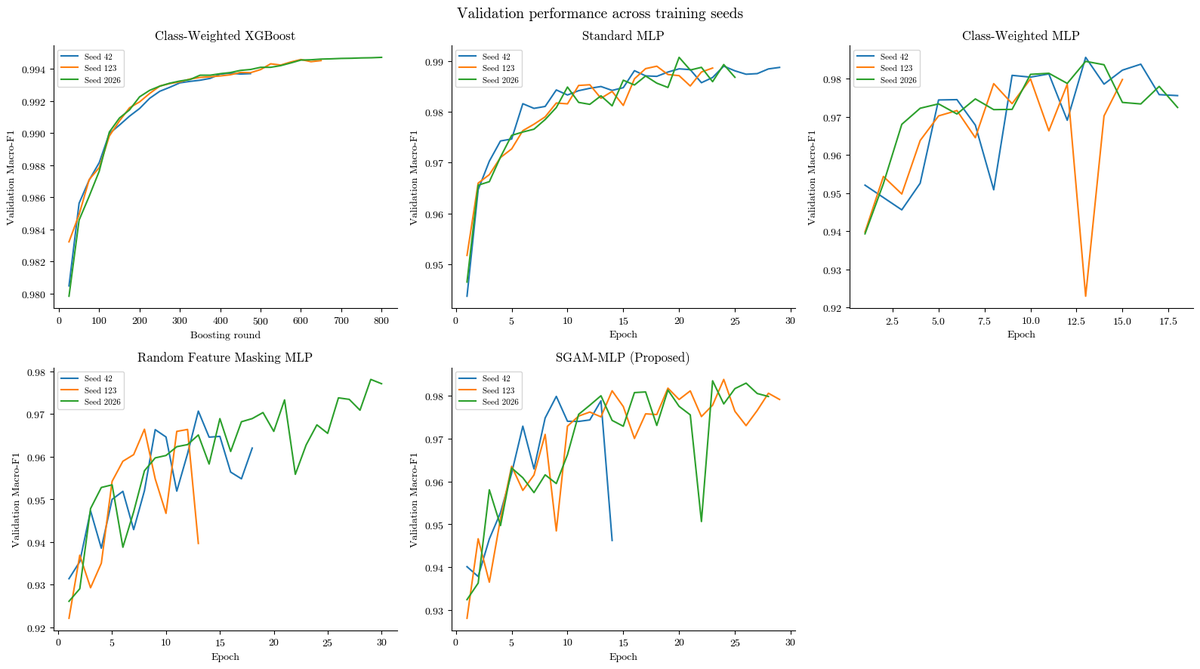

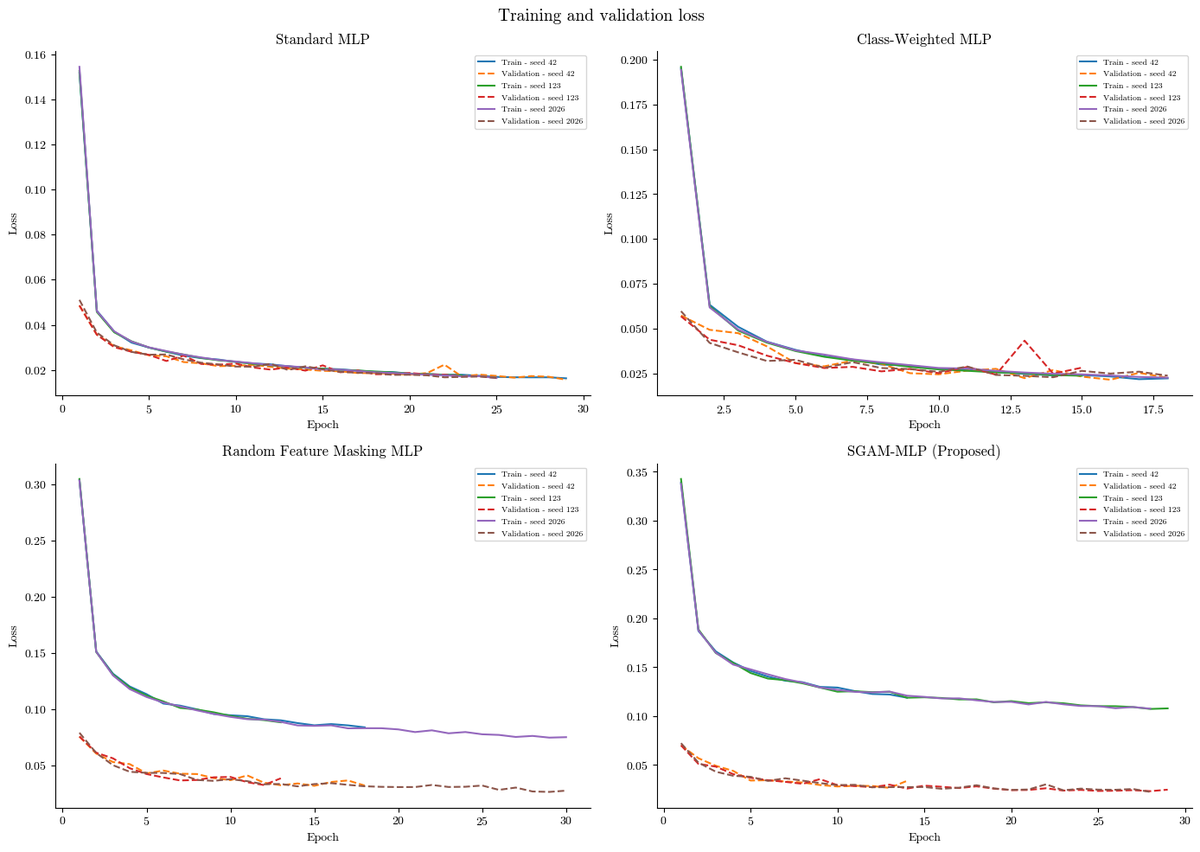

In [ ]:
# @title Final report 2 - validation and loss curves
if STAGE == "REPORT":
    publication_validation_curves(CTX)
    publication_loss_curves(CTX)


### Robustness under source-group loss


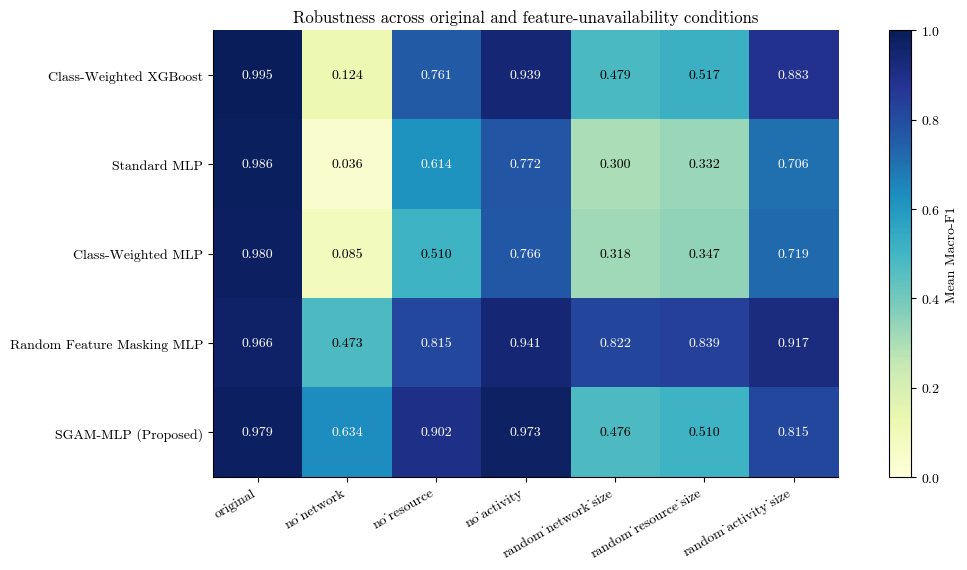


SGAM-MLP DEGRADED-INPUT MACRO-F1


,Condition,Macro-F1
0,No Activity,0.9729
1,No Network,0.6338
2,No Resource,0.9021


In [ ]:
# @title Final report 3 - robustness summary
if STAGE == "REPORT":
    publication_robustness_heatmap(CTX, all_metrics)

    sgam_degraded = (all_metrics[
        (all_metrics["method"] == "MLP_CW_Group") &
        (all_metrics["condition"].isin(["no_activity", "no_resource", "no_network"]))
    ].groupby("condition", as_index=False)["macro_f1"].mean())

    sgam_degraded["Condition"] = sgam_degraded["condition"].map({
        "no_activity": "No Activity",
        "no_resource": "No Resource",
        "no_network": "No Network",
    })
    sgam_degraded["Macro-F1"] = sgam_degraded["macro_f1"].map(lambda v: f"{v:.4f}")

    print("\nSGAM-MLP DEGRADED-INPUT MACRO-F1")
    display(sgam_degraded[["Condition", "Macro-F1"]])


### Confusion matrices


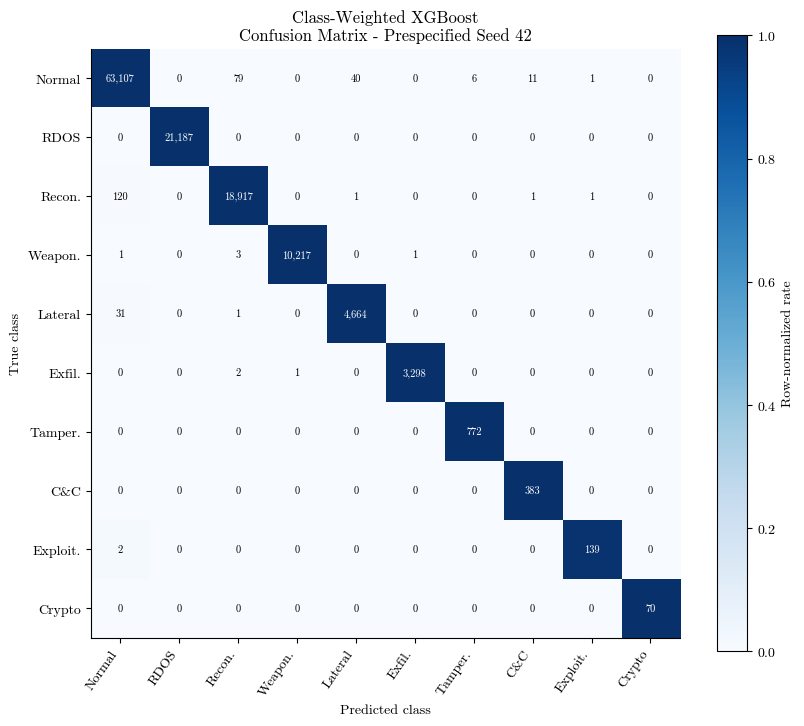

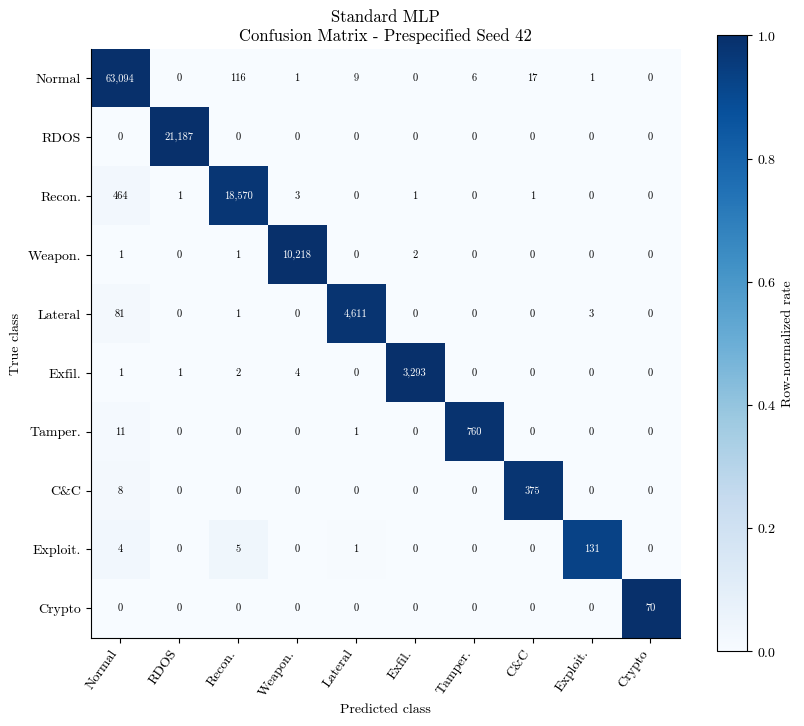

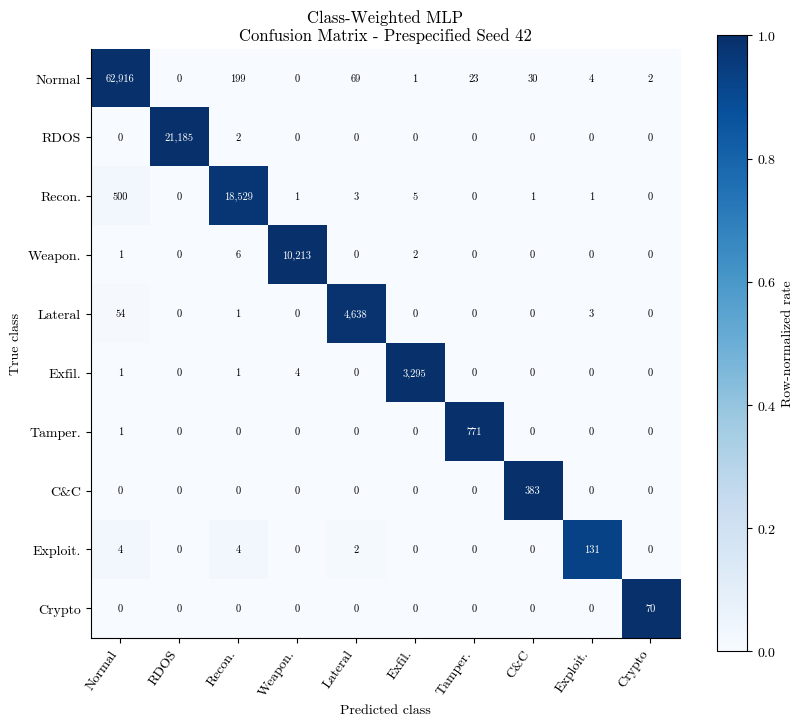

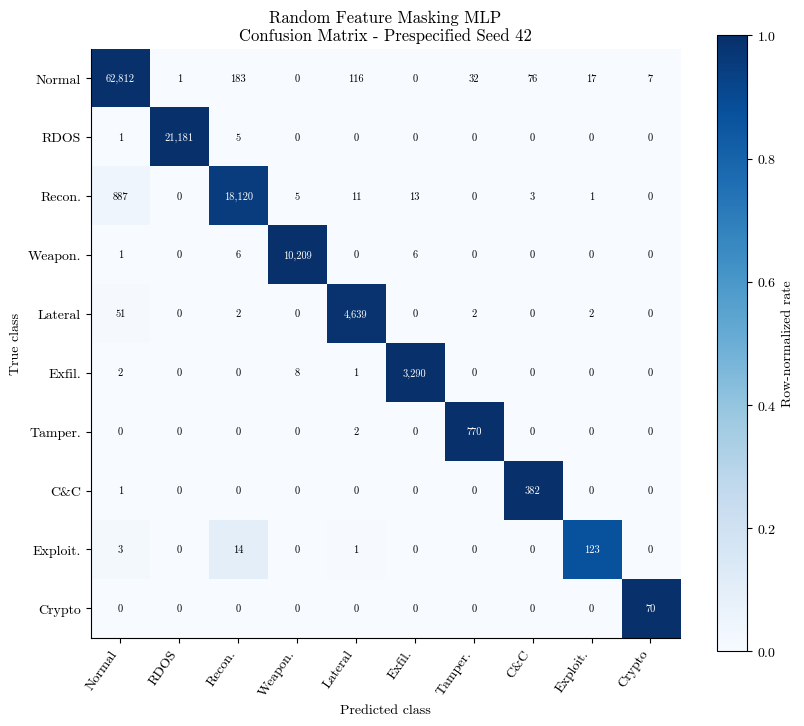

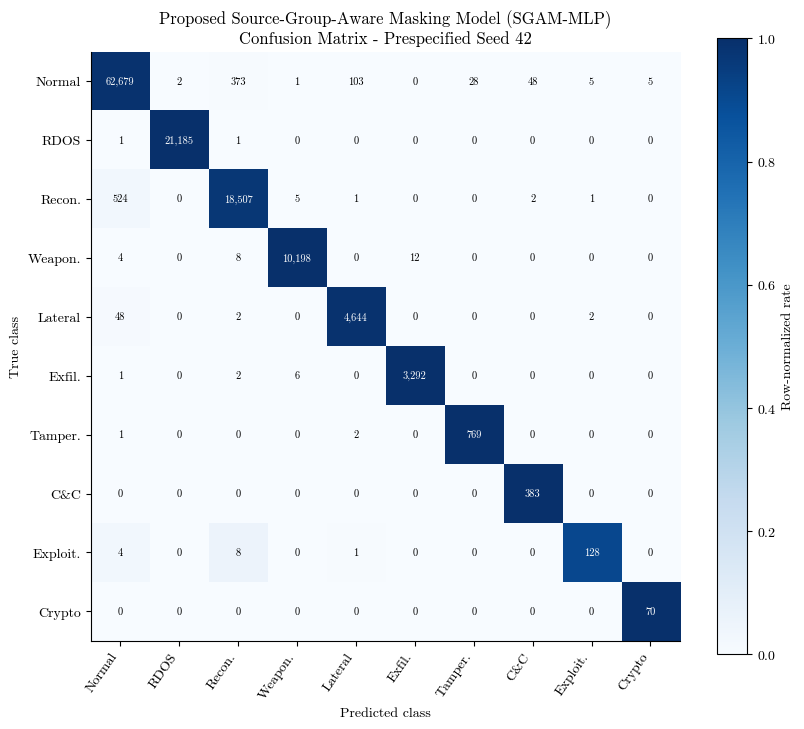

Five model confusion matrices generated successfully.


In [ ]:
# @title Final report 4 - confusion matrices
if STAGE == "REPORT":
    publication_confusion_matrices(CTX)


### Class-wise discrimination and uncertainty


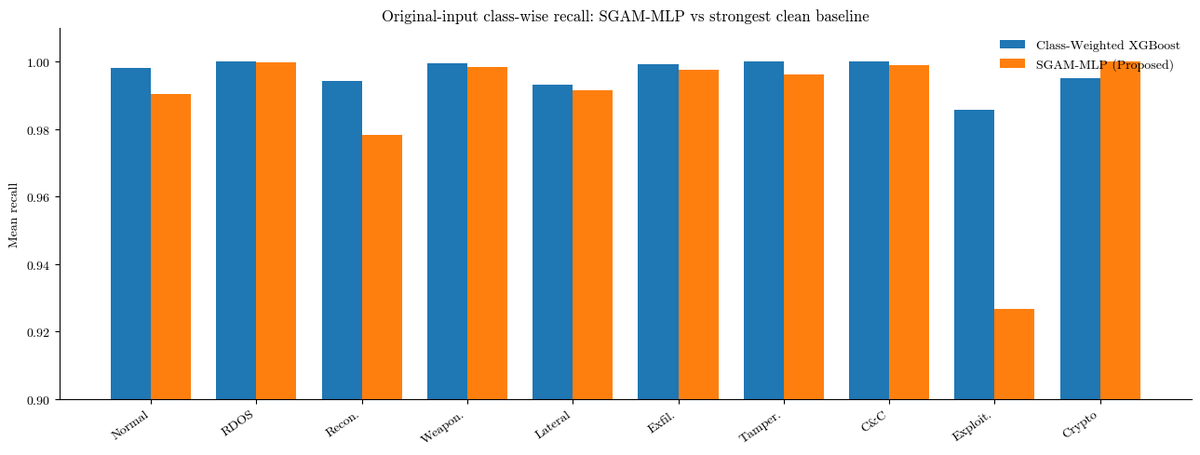

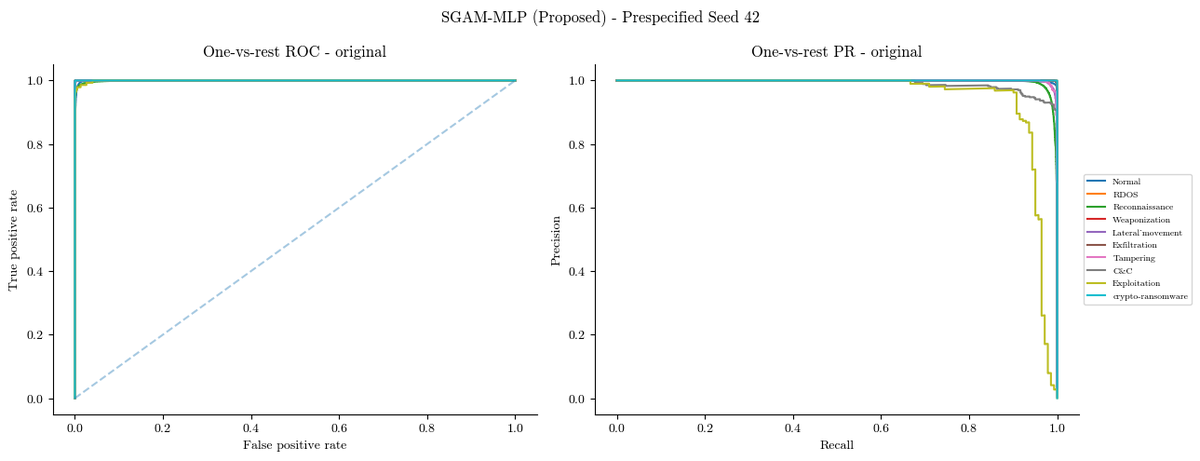

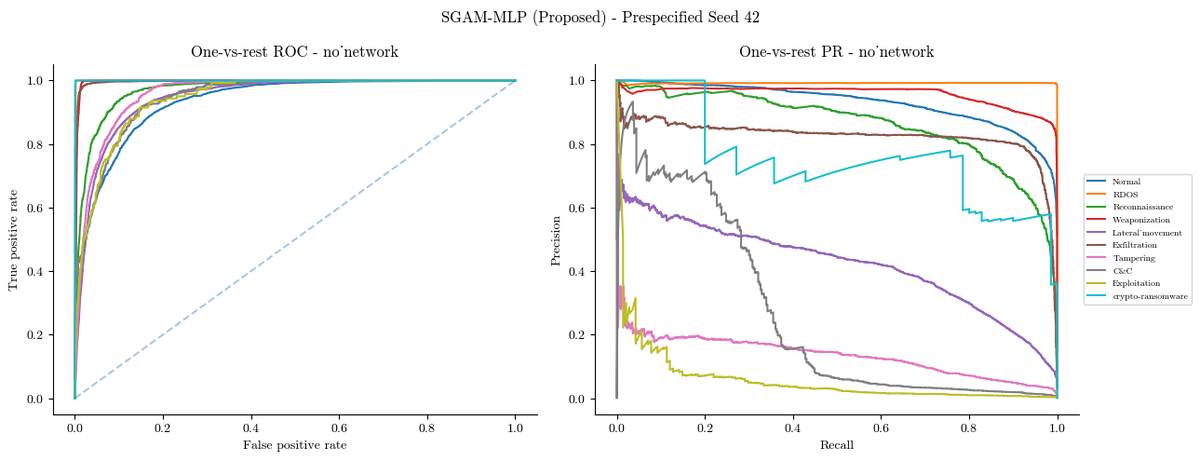

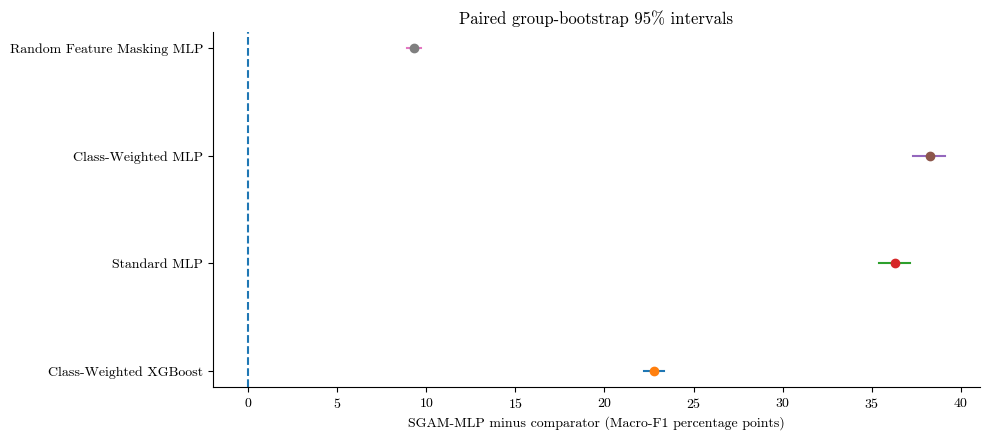

In [ ]:
# @title Final report 5 - recall, ROC/PR and bootstrap
if STAGE == "REPORT":
    publication_recall_comparison(CTX, per_class)
    publication_roc_pr(CTX)
    publication_uncertainty(CTX, ci)


### Statistical analysis


In [ ]:
# @title Final report 6 - statistical tests
if STAGE == "REPORT":
    publication_statistical_tests(CTX, all_metrics)



STATISTICAL ANALYSIS - supporting matched-block evidence


,test,metric,matched_blocks,block_definition,statistic,p_value
0,Friedman,Macro-F1,9,3 seeds × 3 prespecified missing-group conditions,33.511111,9.386181e-07


,comparison,metric,matched_blocks,mean_difference_pp,median_difference_pp,wilcoxon_statistic,p_value_raw,rank_biserial_effect,p_value_holm,significant_at_0_05
0,SGAM-MLP vs Class-Weighted XGBoost,Macro-F1,9,22.790029,13.735382,0.0,0.003906,1.0,0.015625,True
1,SGAM-MLP vs Standard MLP,Macro-F1,9,36.269422,29.972040,0.0,0.003906,1.0,0.015625,True
2,SGAM-MLP vs Class-Weighted MLP,Macro-F1,9,38.244856,39.431000,0.0,0.003906,1.0,0.015625,True
3,SGAM-MLP vs Random Feature Masking MLP,Macro-F1,9,9.317720,10.690810,0.0,0.003906,1.0,0.015625,True


Positive rank-biserial effect favors SGAM-MLP. The paired group-bootstrap remains the cluster-aware uncertainty analysis.

Generating LIME explanation for SGAM-MLP...


### LIME local explanation


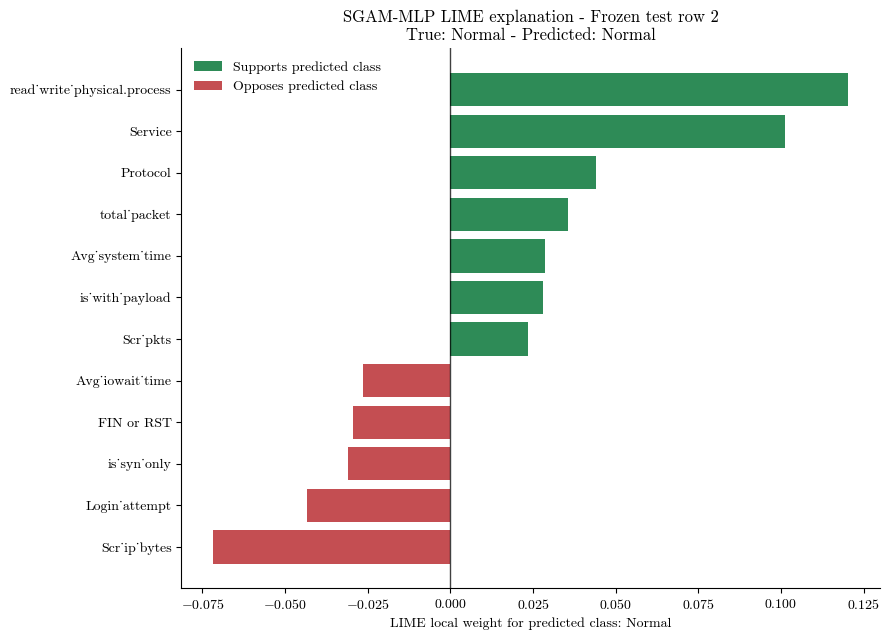

,raw_feature,lime_local_effect,abs_effect
13,Scr_ip_bytes,-0.071788,0.071788
48,Login_attempt,-0.043422,0.043422
7,is_syn_only,-0.030945,0.030945
11,FIN or RST,-0.029519,0.029519
30,Avg_iowait_time,-0.026493,0.026493
12,Scr_pkts,0.023466,0.023466
10,is_with_payload,0.028038,0.028038
28,Avg_system_time,0.028523,0.028523
17,total_packet,0.035708,0.035708
54,Protocol,0.044051,0.044051


In [ ]:
# @title Final report 7 - LIME explanation
if STAGE == "REPORT":
    print("\nGenerating LIME explanation for SGAM-MLP...")
    lime_table = publication_lime(CTX)
    display(lime_table)


### SHAP global explanation



Generating SHAP global feature importance for SGAM-MLP...


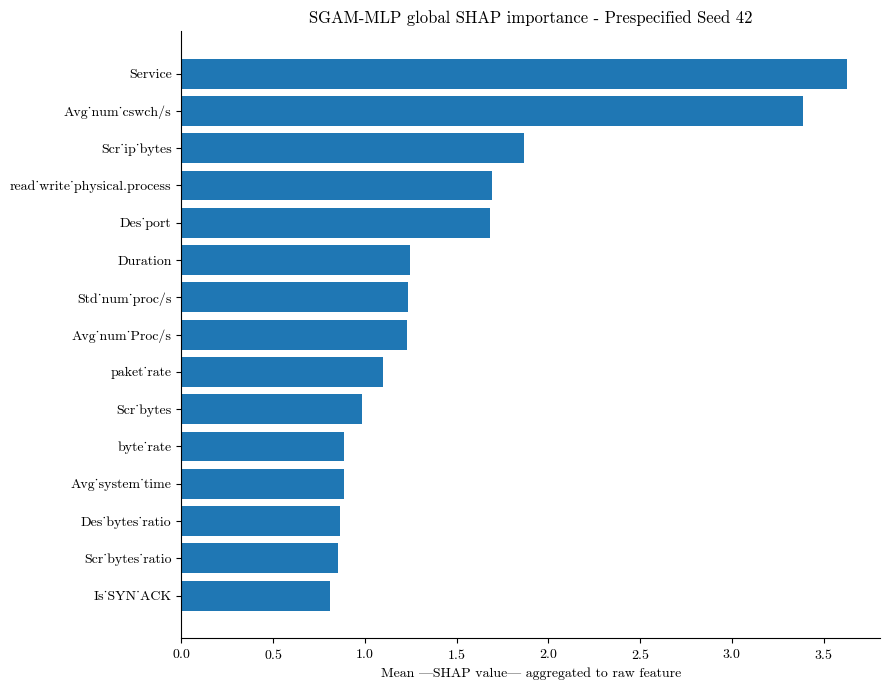

,raw_feature,mean_abs_shap
55,Service,3.626159
46,Avg_num_cswch/s,3.386265
13,Scr_ip_bytes,1.867140
52,read_write_physical.process,1.693564
1,Des_port,1.680542
2,Duration,1.247796
45,Std_num_proc/s,1.236376
44,Avg_num_Proc/s,1.229551
18,paket_rate,1.096452
3,Scr_bytes,0.985911



FINAL REPORTING OUTPUTS COMPLETE
Added: professional model naming, publication-ready Table 1, 5 confusion matrices, training/validation loss, two-color signed LIME, SHAP, Friedman test, Wilcoxon post-hoc tests, Holm correction and rank-biserial effect sizes.


In [ ]:
# @title Final report 8 - SHAP explanation and completion
if STAGE == "REPORT":
    print("\nGenerating SHAP global feature importance for SGAM-MLP...")
    shap_table = publication_shap(CTX)
    display(shap_table.head(15))

    print("\nFINAL REPORTING OUTPUTS COMPLETE")
    print("Included: professional model naming, mean-only Table 1, validation and loss curves, "
          "robustness diagnostics, five confusion matrices, class-wise recall, ROC/PR, "
          "paired bootstrap, Friedman/Wilcoxon/Holm/effect size, LIME and SHAP.")


## Final Completion Check

The final cell confirms that all planned model/seed combinations were trained and evaluated and shows the experiment/output locations used by the notebook.


In [ ]:
# @title Final status and file locations
print("Current study:", CTX["root"])
final_status = status(CTX).copy()
final_status["Model"] = final_status["method"].map(MODEL_SHORT)
final_status = final_status[["Model", "seed", "trained", "evaluated"]].rename(columns={"seed": "Seed"})
completed = int((final_status["trained"] & final_status["evaluated"]).sum())
print(f"Completed model/seed runs: {completed}/{len(final_status)}")
display(final_status)
storage_check(CTX)
print("Original dataset:", CTX["csv"])
print("Tables and figures:", CTX["root"] / "report")
print("Final notebook snapshot: all planned model/seed runs are complete.")


Current study: /content/drive/MyDrive/XIIoTID_Research/experiments/source_group_v1
Completed model/seed runs: 15/15


,Model,Seed,trained,evaluated
0,Class-Weighted XGBoost,42,True,True
1,Class-Weighted XGBoost,123,True,True
2,Class-Weighted XGBoost,2026,True,True
3,Standard MLP,42,True,True
4,Standard MLP,123,True,True
5,Standard MLP,2026,True,True
6,Class-Weighted MLP,42,True,True
7,Class-Weighted MLP,123,True,True
8,Class-Weighted MLP,2026,True,True
9,Random Feature Masking MLP,42,True,True


Experiment artifacts: 516.2 MiB (CSV excluded).
Dataset: /content/drive/MyDrive/XIIoTID_Research/data/X-IIoTID_dataset.csv
Final tables/figures: /content/drive/MyDrive/XIIoTID_Research/experiments/source_group_v1/report
Final notebook snapshot: all 15/15 planned model-seed runs are complete; no execution errors are stored.
